In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import yfinance as yf
from dateutil import parser

df_dates = pd.read_csv("RA_Clayton/Data/sp500_transcripts_history_full.csv")

def extraire_date_universelle(chaine):
    if not isinstance(chaine, str):
        return None
    
    debut_texte = chaine[:150]
    match = re.search(r'([A-Z][a-z]{2,8}\s+\d{1,2}(?:st|nd|rd|th)?[\s,]+\d{4})', debut_texte)
    
    if match:
        date_str = match.group(1)
        try:
            parsed_date = parser.parse(date_str)
            return parsed_date
        except:
            pass
    return None

df_dates["exact_date"] = df_dates['content'].apply(extraire_date_universelle)
df_dates = df_dates.dropna(subset=['exact_date'])

df_dates["quarter_v2"] = "Q" + df_dates["exact_date"].dt.quarter.astype(str).replace('<NA>', 'NaN').replace('nan', 'NaN')
df_dates["year_v2"] = df_dates["exact_date"].dt.year.astype("Int64")

data = pd.read_csv('RA_Clayton/Data/results_final_flattened_0.csv')
data = data.merge(df_dates, on=['company', 'year', 'quarter'], how='inner')
data = data.copy()

colonnes_a_supprimer = ['date_str', 'quarter', 'year', 'content', 'url', 'title']
data.drop(columns=[c for c in colonnes_a_supprimer if c in data.columns], inplace=True, errors='ignore')
data.rename(columns={'quarter_v2': 'quarter', 'year_v2': 'year'}, inplace=True)

tech = [
    "Apple Inc. (AAPL)", "Apple (AAPL)", "Microsoft Corporation (MSFT)", "Microsoft (MSFT)",
    "Nvidia Corporation (NVDA)", "Nvidia (NVDA)", "Alphabet Inc. (GOOGL)", "Alphabet (GOOGL)",
    "Amazon.com Inc. (AMZN)", "Amazon (AMZN)", "Meta Platforms (META)", "Meta (META)",
    "Tesla Inc. (TSLA)", "Tesla (TSLA)", "Broadcom Inc. (AVGO)", "Broadcom (AVGO)",
    "Adobe Inc. (ADBE)", "Adobe (ADBE)", "Salesforce (CRM)", "Cisco Systems (CSCO)", 
    "Cisco (CSCO)", "Oracle Corporation (ORCL)", "Oracle (ORCL)", "Intel Corporation (INTC)", 
    "Intel (INTC)", "AMD (AMD)", "Netflix (NFLX)", "IBM (IBM)"
]

finance = [
    "JPMorgan Chase (JPM)", "Visa Inc. (V)", "Visa (V)", "Mastercard (MA)", 
    "Bank of America (BAC)", "Wells Fargo (WFC)", "Goldman Sachs (GS)", 
    "Morgan Stanley (MS)", "American Express (AXP)", "Berkshire Hathaway (BRK-B)"
]

conso = [
    "Walmart (WMT)", "Costco (COST)", "Coca-Cola (KO)", "PepsiCo (PEP)", 
    "McDonald's (MCD)", "Nike (NKE)", "Starbucks (SBUX)", "Home Depot (HD)", 
    "Disney (DIS)", "Procter & Gamble (PG)"
]

health = [
    "Eli Lilly (LLY)", "UnitedHealth (UNH)", "Johnson & Johnson (JNJ)", 
    "Merck (MRK)", "AbbVie (ABBV)", "Pfizer (PFE)", "Abbott (ABT)", 
    "Thermo Fisher (TMO)"
]

industry_and_energy = [
    "ExxonMobil (XOM)", "Chevron (CVX)", "General Electric (GE)", "Boeing (BA)", 
    "Lockheed Martin (LMT)", "Caterpillar (CAT)", "RTX (RTX)", "Northrop Grumman (NOC)", 
    "General Dynamics (GD)", "L3Harris (LHX)", "Howmet Aerospace (HWM)", "Deere (DE)", 
    "Cummins (CMI)", "PACCAR (PCAR)", "Wabtec (WAB)", "Parker-Hannifin (PH)", 
    "Carrier Global (CARR)", "Johnson Controls (JCI)", "Rockwell Automation (ROK)", 
    "Dover (DOV)", "Ingersoll Rand (IR)", "Fortive (FTV)", "Snap-on (SNA)", 
    "Nordson (NDSN)", "Axon Enterprise (AXON)", "3M (MMM)", "Eaton (ETN)", 
    "Emerson Electric (EMR)", "Honeywell (HON)", "Otis (OTIS)", "Trane Technologies (TT)"
]

transports_and_logistics = [
    "UPS (UPS)", "FedEx (FDX)", "CSX (CSX)", "Norfolk Southern (NSC)", 
    "Old Dominion Freight (ODFL)", "J.B. Hunt (JBHT)", "Union Pacific (UNP)",
    "C.H. Robinson (CHRW)", "Expeditors (EXPD)"
]

airlines = [
    "Delta Air Lines (DAL)", "Southwest Airlines (LUV)", "United Airlines (UAL)"
]

construction = [
    "Vulcan Materials (VMC)", "Martin Marietta (MLM)", "Quanta Services (PWR)", 
    "Jacobs Solutions (J)", "Waste Management (WM)", "Republic Services (RSG)", 
    "Cintas (CTAS)", "Fastenal (FAST)"
]

all_companies = tech + finance + conso + health + industry_and_energy + transports_and_logistics + airlines + construction

grouped_by_ticker = {}
for item in all_companies:
    match = re.search(r'\(([^)]+)\)', item)
    if match:
        ticker = match.group(1)
        name_part = item[:match.start()].strip()
        if ticker not in grouped_by_ticker:
            grouped_by_ticker[ticker] = []
        grouped_by_ticker[ticker].append(name_part)

rename_mapping = {}
for item in all_companies:
    match = re.search(r'\(([^)]+)\)', item)
    if match:
        ticker = match.group(1)
        common_name = os.path.commonprefix(grouped_by_ticker[ticker]).strip()
        rename_mapping[item] = f"{common_name} ({ticker})"

data['company'] = data['company'].replace(rename_mapping)

def get_ticker_from_company(name):
    match = re.search(r'\(([^)]+)\)', name)
    return match.group(1) if match else name

data['ticker'] = data['company'].apply(get_ticker_from_company)

sector_mapping = {}
for c in tech: sector_mapping[rename_mapping.get(c, c)] = 'Tech'
for c in finance: sector_mapping[rename_mapping.get(c, c)] = 'Finance'
for c in conso: sector_mapping[rename_mapping.get(c, c)] = 'Consumer'
for c in health: sector_mapping[rename_mapping.get(c, c)] = 'Health'
for c in industry_and_energy: sector_mapping[rename_mapping.get(c, c)] = 'Industry & Energy'
for c in transports_and_logistics: sector_mapping[rename_mapping.get(c, c)] = 'Transports'
for c in airlines: sector_mapping[rename_mapping.get(c, c)] = 'Airlines'
for c in construction: sector_mapping[rename_mapping.get(c, c)] = 'Construction'

data['sector'] = data['company'].map(sector_mapping)

def get_sectors_yfinance(ticker):
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        if info and isinstance(info, dict):
            return info.get('sector', 'Other')
    except Exception:
        pass
    return 'Other'

missing_mask = data['sector'].isna()
if missing_mask.any():
    data.loc[missing_mask, 'sector'] = data.loc[missing_mask, 'ticker'].apply(get_sectors_yfinance)

data['sector'] = data['sector'].fillna('Other')
data.drop_duplicates(inplace=True)

print("\n--- REPARTITION CALENDAIRE REELLE DES TRANSCRIPTS ---")
repartition = data.groupby(['year', 'quarter']).size().reset_index(name='nombre_transcripts')
repartition = repartition.sort_values(by=['year', 'quarter'])
print(repartition.to_string(index=False))

print("-" * 60)
print(f"Total des transcripts : {len(data)}")
print(data.groupby('sector')['company'].nunique())
print("-" * 60)


--- REPARTITION CALENDAIRE REELLE DES TRANSCRIPTS ---
 year quarter  nombre_transcripts
 2022      Q2                   3
 2022      Q3                   6
 2022      Q4                  10
 2023      Q1                  13
 2023      Q2                  28
 2023      Q3                  47
 2023      Q4                  49
 2024      Q1                  48
 2024      Q2                  51
 2024      Q3                  47
 2024      Q4                  57
 2025      Q1                  54
 2025      Q2                   5
 2025      Q3                  41
 2025      Q4                  16
 2026      Q1                   5
------------------------------------------------------------
Total des transcripts : 480
sector
Airlines              2
Construction          5
Consumer              9
Finance               8
Health                7
Industry & Energy    22
Tech                 15
Transports            6
Name: company, dtype: int64
---------------------------------------------------

In [97]:
data.head()

,company,tariffs_summary,tariffs_effect_any,tariffs_effect_current,tariffs_effect_future,tariffs_investment_up_imposing,tariffs_investment_up_receiving,tariffs_investment_up_third_party,tariffs_investment_down_imposing,tariffs_investment_down_receiving,...,sanctions_hs_heading_explanation,sanctions_hs_subheading_explanation,exports_hs_chapter_explanation,exports_hs_heading_explanation,exports_hs_subheading_explanation,sector,exact_date,quarter,year,ticker
0,Apple (AAPL),[Part 5] Apple is monitoring the situation reg...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2025-01-30,Q1,2025,AAPL
1,Apple (AAPL),"[Part 1] Apple is affected by tariffs, with es...",1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2025-07-31,Q3,2025,AAPL
2,Microsoft (MSFT),Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2024-10-30,Q4,2024,MSFT
3,Microsoft (MSFT),[Part 3] Microsoft's Windows OEM revenue may b...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2025-01-29,Q1,2025,MSFT
4,Microsoft (MSFT),Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,Tech,2025-07-30,Q3,2025,MSFT


In [98]:
cols_imposing = [c for c in data.columns if 'countries_imposing' in c]
prefixes = [c.replace('countries_imposing', '') for c in cols_imposing]

def process_excluding_various(row, col_imp, col_rec):
    def to_set(val):
        if pd.isna(val) or str(val).lower() == 'nan':
            return set()
        s = str(val).replace('[', '').replace(']', '').replace("'", "").replace(';', ',')
        return set([c.strip() for c in s.split(',') if c.strip()])

    set_imp = to_set(row[col_imp])
    set_rec = to_set(row[col_rec])

    common_elements = set_imp.intersection(set_rec)
    real_countries_in_common = [c for c in common_elements if c.lower() != 'various']

    if len(real_countries_in_common) > 0:
        merged = sorted(list(set_imp.union(set_rec)))
        return ', '.join(merged), ', '.join(merged)
    else:
        return ', '.join(sorted(list(set_imp))), ', '.join(sorted(list(set_rec)))

for pref in prefixes:
    c_imp = f"{pref}countries_imposing"
    c_rec = f"{pref}countries_receiving"
    
    if c_imp in data.columns and c_rec in data.columns:
        res = data.apply(lambda r: process_excluding_various(r, c_imp, c_rec), axis=1)
        data[c_imp] = res.map(lambda x: x[0])
        data[c_rec] = res.map(lambda x: x[1])

In [99]:
print(data.iloc[49][['tariffs_countries_imposing', 'tariffs_countries_receiving']])

tariffs_countries_imposing     
tariffs_countries_receiving    
Name: 49, dtype: object


In [100]:
import pandas as pd
import plotly.graph_objects as go

prefixes = ['tariffs_', 'sanctions_', 'exports_']
df_list = []

for prefix in prefixes:
    col_imposing = f"{prefix}countries_imposing"
    col_receiving = f"{prefix}countries_receiving"
    
    temp_df = data[[col_imposing, 'sector', col_receiving]].copy()
    
    temp_df[col_imposing] = temp_df[col_imposing].fillna('Unspecified')
    temp_df[col_receiving] = temp_df[col_receiving].fillna('Unspecified')
    
    temp_df = temp_df[~((temp_df[col_imposing] == 'Unspecified') & (temp_df[col_receiving] == 'Unspecified'))]
    
    temp_df.rename(columns={
        col_imposing: 'countries_imposing',
        col_receiving: 'countries_receiving'
    }, inplace=True)
    
    df_list.append(temp_df)

df_sankey = pd.concat(df_list, ignore_index=True)

for col in ['countries_imposing', 'countries_receiving']:
    df_sankey[col] = df_sankey[col].astype(str).str.replace(r"[\[\]'\"]", "", regex=True)
    df_sankey[col] = df_sankey[col].str.replace(";", ",")
    df_sankey[col] = df_sankey[col].str.split(',')

df_sankey = df_sankey.explode('countries_imposing').explode('countries_receiving')

for col in ['countries_imposing', 'sector', 'countries_receiving']:
    df_sankey[col] = df_sankey[col].astype(str).str.strip()
    df_sankey = df_sankey[df_sankey[col] != '']

flow_counts = df_sankey.groupby(['countries_imposing', 'sector', 'countries_receiving']).size().reset_index(name='value')
flow_counts = flow_counts.sort_values('value', ascending=False)

source_sizes = flow_counts.groupby('countries_imposing')['value'].sum().sort_values(ascending=False)
sector_sizes = flow_counts.groupby('sector')['value'].sum().sort_values(ascending=False)
target_sizes = flow_counts.groupby('countries_receiving')['value'].sum().sort_values(ascending=False)

sources = source_sizes.index.tolist()
sectors = sector_sizes.index.tolist()
targets = target_sizes.index.tolist()

labels = sources + sectors + targets

source_dict = {name: i for i, name in enumerate(sources)}
sector_dict = {name: i + len(sources) for i, name in enumerate(sectors)}
target_dict = {name: i + len(sources) + len(sectors) for i, name in enumerate(targets)}

muted_pastels = [
    '#E698A0', '#E6C298', '#D9D973', '#98E6AB', '#98C5E6',
    '#D7A3E0', '#C5D4AD', '#E6A6C6', '#A6DEDC', '#C9C9DE',
    '#E6B3C0', '#96CCB9', '#AAB2CF', '#E6BC9E', '#E67E86'
]

def hex_to_rgba(hex_color, alpha=0.55):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r}, {g}, {b}, {alpha})'

pays_colors_node = {}
pays_colors_link = {}

for i, pays in enumerate(sources):
    couleur = muted_pastels[i % len(muted_pastels)]
    pays_colors_node[pays] = couleur
    pays_colors_link[pays] = hex_to_rgba(couleur, 0.55)

node_colors = []
for node in labels:
    if node in sources:
        node_colors.append(pays_colors_node[node])
    elif node in targets and node not in sources:
        node_colors.append('#E8E8E8')
    else:
        node_colors.append('#CCCCCC')

couleurs_base = [pays_colors_link[pays] for pays in flow_counts['countries_imposing']]
link_colors = couleurs_base + couleurs_base

def get_y_positions(n):
    if n == 0: return []
    if n == 1: return [0.5]
    return [0.05 + i * (0.90 / (n - 1)) for i in range(n)]

x_pos = [0.01] * len(sources) + [0.5] * len(sectors) + [0.99] * len(targets)
y_pos = get_y_positions(len(sources)) + get_y_positions(len(sectors)) + get_y_positions(len(targets))

source_to_sector_sources = flow_counts['countries_imposing'].map(source_dict).tolist()
source_to_sector_targets = flow_counts['sector'].map(sector_dict).tolist()

sector_to_target_sources = flow_counts['sector'].map(sector_dict).tolist()
sector_to_target_targets = flow_counts['countries_receiving'].map(target_dict).tolist()

sankey_sources = source_to_sector_sources + sector_to_target_sources
sankey_targets = source_to_sector_targets + sector_to_target_targets
sankey_values = flow_counts['value'].tolist() + flow_counts['value'].tolist()

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="white", width=1),
        label=labels,
        color=node_colors,
        x=x_pos,
        y=y_pos
    ),
    link=dict(
        source=sankey_sources,
        target=sankey_targets,
        value=sankey_values,
        color=link_colors
    )
)])

fig.update_layout(
    title_text="Characterizing pressure: from who to whom using what",
    font_size=12,
    height=800,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

try:
    fig.show()
except:
    fig.write_html("sankey_pastels_fonces.html")

In [101]:
# 1. Chargement et fusion avec le calendrier exact
data_first_prompt = pd.read_csv('results_extraction.csv')
data_first_prompt = data_first_prompt.merge(df_dates, on=['company', 'year', 'quarter'], how='inner')

# 2. Suppression SÉCURISÉE des anciennes colonnes temporelles
colonnes_a_supprimer = ['date', 'date_str', 'exact_date', 'quarter', 'year', 'content', 'url', 'title']
data_first_prompt.drop(columns=[c for c in colonnes_a_supprimer if c in data_first_prompt.columns], inplace=True, errors='ignore')

# 3. Bascule sur le calendrier réel
data_first_prompt.rename(columns={'quarter_v2': 'quarter', 'year_v2': 'year'}, inplace=True)

# 4. Création du Ticker
data_first_prompt['ticker'] = data_first_prompt['company'].apply(get_ticker_from_company)

# COUP DE FILET : On supprime la variable 'company' (pour éviter _x et _y lors du merge)
data_first_prompt.drop(columns=['company'], inplace=True, errors='ignore')

# ATTENTION : On NE recalcule PAS le secteur avec yfinance ! 
# La table 'data' (results_correct_geoeconomics) a déjà la colonne 'sector'. 
# Le merge va l'importer automatiquement et proprement !

# 5. FUSION FINALE
data_merged_outer = pd.merge(data_first_prompt, data, on=['ticker', 'year', 'quarter'], how='outer', indicator=True)

# 6. ANALYSE DES MISMATCHES
mismatches_df = data_merged_outer[data_merged_outer['_merge'] != 'both']
print("-" * 60)
print(f"Nombre de lignes uniques non correspondantes : {len(mismatches_df)}")
print("-" * 60)

# Pour t'aider à comprendre d'où vient l'erreur, on affiche la source des orphelins :
if len(mismatches_df) > 0:
    print("Détail des non-correspondances :")
    print(mismatches_df['_merge'].value_counts())
    print("\nExemple de lignes orphelines :")
    print(mismatches_df[['ticker', 'year', 'quarter', '_merge']].head(5))

------------------------------------------------------------
Nombre de lignes uniques non correspondantes : 7
------------------------------------------------------------
Détail des non-correspondances :
_merge
left_only     7
right_only    0
both          0
Name: count, dtype: int64

Exemple de lignes orphelines :
    ticker  year quarter     _merge
78     BAC  2026      Q1  left_only
172     GE  2024      Q3  left_only
184     GS  2023      Q3  left_only
343    NSC  2024      Q2  left_only
428     TT  2024      Q4  left_only


In [102]:
print(data_merged_outer.columns)

Index(['explication', 'tariffs_any', 'sanctions_any', 'export_controls_any',
       'boycotts_any', 'investment_screening_any', 'geo_subsidies_any',
       'geoeconomic_any', 'sector_x', 'quarter',
       ...
       'tariffs_hs_subheading_explanation', 'sanctions_hs_chapter_explanation',
       'sanctions_hs_heading_explanation',
       'sanctions_hs_subheading_explanation', 'exports_hs_chapter_explanation',
       'exports_hs_heading_explanation', 'exports_hs_subheading_explanation',
       'sector_y', 'exact_date', '_merge'],
      dtype='object', length=456)


In [103]:
import kaleido
import pandas as pd
import plotly.graph_objects as go
import yfinance as yf
import re

data_merged = data_merged_outer[data_merged_outer['_merge'] == 'both'].copy()
data_merged.drop(columns=['_merge'], inplace=True)
data_merged['sector'] = data_merged['sector_y'].fillna(data_merged['sector_x'])

measures = ['tariffs_any', 'export_controls_any', 'sanctions_any']

noms_mesures = {
    'tariffs_any': 'Tariffs',
    'export_controls_any': 'Export Controls',
    'sanctions_any': 'Sanctions'
}

prefix_map = {
    'tariffs_any': 'tariffs_',
    'export_controls_any': 'exports_',
    'sanctions_any': 'sanctions_'
}

muted_pastels = [
    '#E698A0', '#E6C298', '#D9D973', '#98E6AB', '#98C5E6', 
    '#D7A3E0', '#C5D4AD', '#E6A6C6', '#A6DEDC', '#C9C9DE', 
    '#E6B3C0', '#96CCB9', '#AAB2CF', '#E6BC9E', '#E67E86'
]

def hex_to_rgba(hex_color, alpha=0.55):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r}, {g}, {b}, {alpha})'

def get_y_positions(n):
    if n == 0: return []
    if n == 1: return [0.5]
    return [0.05 + i * (0.90 / (n - 1)) for i in range(n)]

country_cache = {}

for measure in measures:
    print(f"Génération du diagramme pour : {noms_mesures[measure]}...")
    
    prefix = prefix_map[measure]
    col_imposing = f"{prefix}countries_imposing"
    col_receiving = f"{prefix}countries_receiving"
    
    df_base = data_merged[data_merged[measure] == 1].copy()
    
    if df_base.empty:
        print(f"⚠️ Aucune donnée pour {measure}. Passage à la suite.")
        continue
        
    df_sankey = df_base[[col_imposing, 'sector', col_receiving]].copy()

    df_sankey[col_imposing] = df_sankey[col_imposing].fillna('Unspecified')
    df_sankey[col_receiving] = df_sankey[col_receiving].fillna('Unspecified')
    df_sankey = df_sankey[~((df_sankey[col_imposing] == 'Unspecified') & (df_sankey[col_receiving] == 'Unspecified'))]

    df_sankey.rename(columns={
        col_imposing: 'countries_imposing',
        col_receiving: 'countries_receiving'
    }, inplace=True)

    for col in ['countries_imposing', 'countries_receiving']:
        df_sankey[col] = df_sankey[col].astype(str).str.replace(r"[\[\]'\"]", "", regex=True)
        df_sankey[col] = df_sankey[col].str.replace(";", ",")
        df_sankey[col] = df_sankey[col].str.split(',')

    df_sankey = df_sankey.explode('countries_imposing').explode('countries_receiving')

    for col in ['countries_imposing', 'sector', 'countries_receiving']:
        df_sankey[col] = df_sankey[col].astype(str).str.strip()
        df_sankey = df_sankey[df_sankey[col] != '']

    def apply_yfinance_rules(row):
        imp = str(row['countries_imposing'])
        rec = str(row['countries_receiving'])
        match_imp = re.search(r'\(([^)]+)\)', imp)
        match_rec = re.search(r'\(([^)]+)\)', rec)
        
        if match_imp or match_rec:
            ticker = match_rec.group(1) if match_rec else match_imp.group(1)
            if ticker not in country_cache:
                try:
                    country_cache[ticker] = yf.Ticker(ticker).info.get('country', 'United States')
                except:
                    country_cache[ticker] = 'United States'
            
            row['countries_receiving'] = country_cache[ticker]
            row['countries_imposing'] = 'Various'
        return row

    if not df_sankey.empty:
        df_sankey = df_sankey.apply(apply_yfinance_rules, axis=1)

    flow_counts = df_sankey.groupby(['countries_imposing', 'sector', 'countries_receiving']).size().reset_index(name='value')
    flow_counts = flow_counts.sort_values('value', ascending=False)

    source_sizes = flow_counts.groupby('countries_imposing')['value'].sum().sort_values(ascending=False)
    sector_sizes = flow_counts.groupby('sector')['value'].sum().sort_values(ascending=False)
    target_sizes = flow_counts.groupby('countries_receiving')['value'].sum().sort_values(ascending=False)

    sources = source_sizes.index.tolist()
    sectors = sector_sizes.index.tolist()
    targets = target_sizes.index.tolist()

    labels = sources + sectors + targets

    source_dict = {name: i for i, name in enumerate(sources)}
    sector_dict = {name: i + len(sources) for i, name in enumerate(sectors)}
    target_dict = {name: i + len(sources) + len(sectors) for i, name in enumerate(targets)}

    pays_colors_node = {}
    pays_colors_link = {}

    for i, pays in enumerate(sources):
        couleur = muted_pastels[i % len(muted_pastels)] 
        pays_colors_node[pays] = couleur
        pays_colors_link[pays] = hex_to_rgba(couleur, 0.55)

    node_colors = []
    for node in labels:
        if node in sources:
            node_colors.append(pays_colors_node[node]) 
        elif node in targets and node not in sources:
            node_colors.append('#E8E8E8')              
        else:
            node_colors.append('#CCCCCC')              

    link_colors = []
    for pays_imposant in flow_counts['countries_imposing']:
        link_colors.append(pays_colors_link.get(pays_imposant, 'rgba(200,200,200,0.5)'))
    for pays_imposant in flow_counts['countries_imposing']:
        link_colors.append(pays_colors_link.get(pays_imposant, 'rgba(200,200,200,0.5)'))

    x_pos = [0.01] * len(sources) + [0.5] * len(sectors) + [0.99] * len(targets)
    y_pos = get_y_positions(len(sources)) + get_y_positions(len(sectors)) + get_y_positions(len(targets))

    source_to_sector_sources = flow_counts['countries_imposing'].map(source_dict).tolist()
    source_to_sector_targets = flow_counts['sector'].map(sector_dict).tolist()

    sector_to_target_sources = flow_counts['sector'].map(sector_dict).tolist()
    sector_to_target_targets = flow_counts['countries_receiving'].map(target_dict).tolist()

    sankey_sources = source_to_sector_sources + sector_to_target_sources
    sankey_targets = source_to_sector_targets + sector_to_target_targets
    sankey_values = flow_counts['value'].tolist() + flow_counts['value'].tolist()

    fig = go.Figure(data=[go.Sankey(
        arrangement = "snap", 
        node = dict(
          pad = 15,
          thickness = 20,
          line = dict(color = "white", width = 1),
          label = labels,
          color = node_colors,
          x = x_pos,
          y = y_pos
        ),
        link = dict(
          source = sankey_sources,
          target = sankey_targets,
          value = sankey_values,
          color = link_colors 
        )
    )])

    fig.update_layout(
        title_text=f"Characterizing pressure: from who to whom using what - <b>{noms_mesures[measure]}</b>",
        font_size=12,
        height=800,
        plot_bgcolor='white',
        paper_bgcolor='white'
    )

    filename_html = f"sankey_{measure}.html"
    filename_png = f"sankey_{measure}.png" 

    try:
        fig.write_image(filename_png, width=1200, height=800, scale=2)
        print(f"✅ Image sauvegardée : {filename_png}")
        
        fig.write_html(filename_html)
        print(f"✅ Page HTML sauvegardée : {filename_html}")
        
        fig.show()
        
    except Exception as e:
        print(f"❌ Erreur lors de la sauvegarde pour {measure}: {e}")
        print("💡 Astuce : Si l'erreur concerne l'export d'image, vérifie que 'kaleido' est bien installé (pip install -U kaleido).")

Génération du diagramme pour : Tariffs...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: E.G. CHINA"}}}


❌ Erreur lors de la sauvegarde pour tariffs_any: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido

💡 Astuce : Si l'erreur concerne l'export d'image, vérifie que 'kaleido' est bien installé (pip install -U kaleido).
Génération du diagramme pour : Export Controls...
❌ Erreur lors de la sauvegarde pour export_controls_any: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido

💡 Astuce : Si l'erreur concerne l'export d'image, vérifie que 'kaleido' est bien installé (pip install -U kaleido).
Génération du diagramme pour : Sanctions...
❌ Erreur lors de la sauvegarde pour sanctions_any: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido

💡 Astuce : Si l'erreur concerne l'export d'image, vérifie que 'kaleido' est bien install

In [104]:
print("Nombre de lignes avec export control et country receiving non vide :")
print(len(data_merged[
    (data_merged['export_controls_any'] == 1) & 
    (data_merged['exports_countries_receiving'].notna()) & 
    (data_merged['exports_countries_receiving'].astype(str).str.strip() != '')
]))

Nombre de lignes avec export control et country receiving non vide :
8


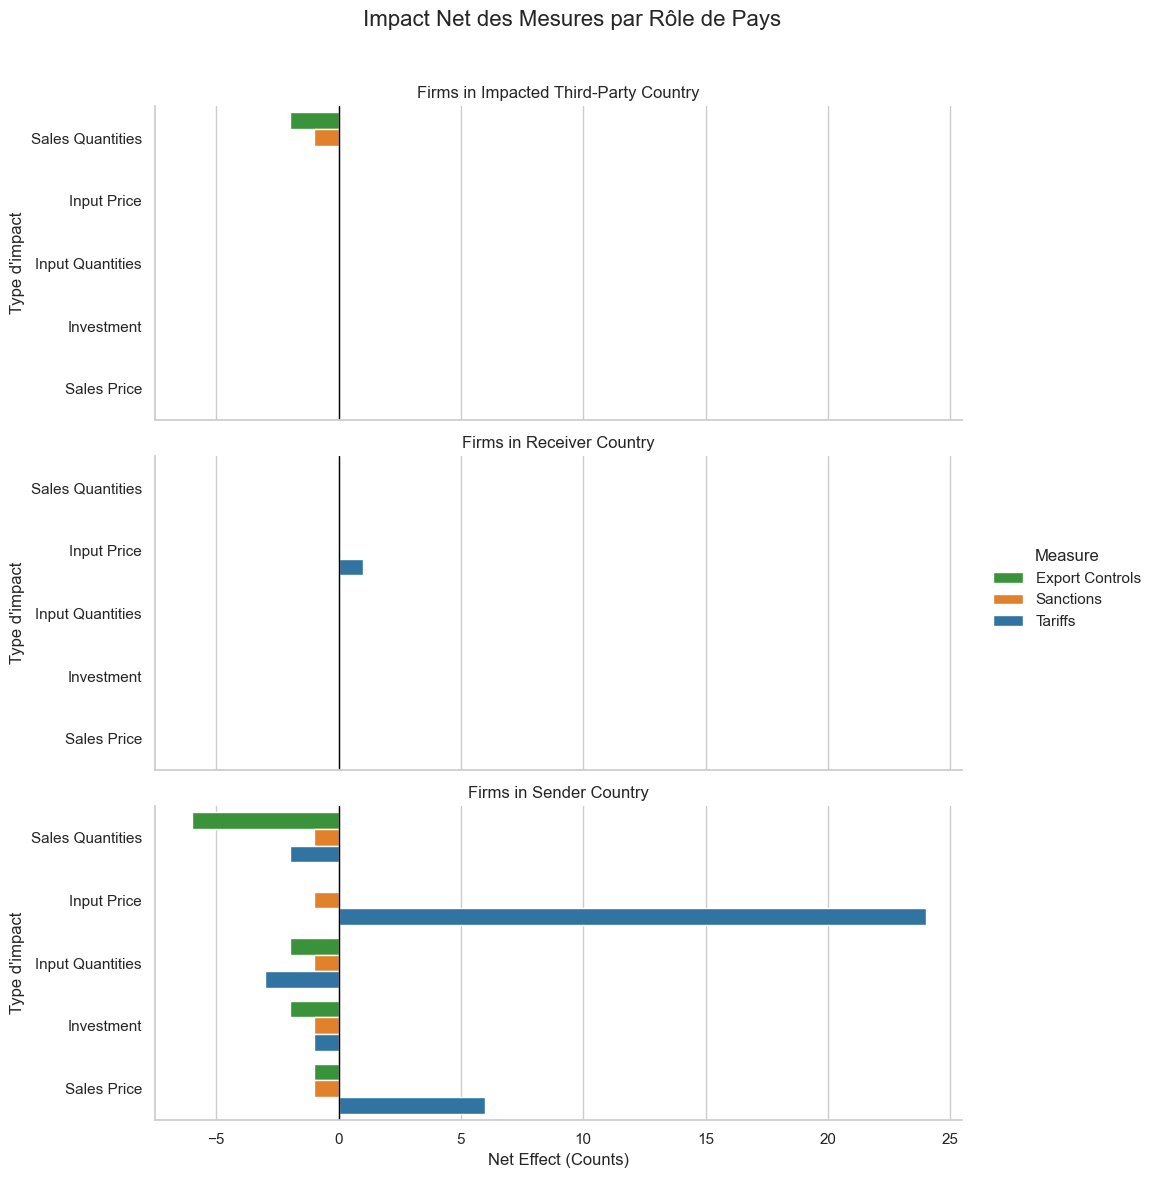

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- 1. PRÉPARATION DES DONNÉES ---
df = data_merged.copy()

country_synonyms = {
    'united states': 'usa', 'us': 'usa', 'america': 'usa',
    'china': 'china', 'prc': 'china',
    'russia': 'russia', 'russian federation': 'russia'
}

def get_ticker_from_company(company):
    if pd.isna(company): return 'UNKNOWN'
    match = re.search(r'\(([^)]+)\)', str(company))
    return match.group(1) if match else str(company)

# Mapping des tickers par défaut
ticker_to_country = {'TTE': 'france', '00981': 'china'}

if 'ticker_x' in df.columns:
    df['ticker'] = df['ticker_x']
elif 'ticker' not in df.columns:
    df['ticker'] = df['company'].apply(get_ticker_from_company)

df['firm_country'] = df['ticker'].apply(lambda x: ticker_to_country.get(str(x).strip(), 'usa') if pd.notna(x) else 'unknown')

measures = {'tariffs_any': 'Tariffs', 'export_controls_any': 'Export Controls', 'sanctions_any': 'Sanctions'}

def find_col(cols, base, measure):
    if measure == 'Tariffs': pxs = ['tariffs_']
    elif measure == 'Export Controls': pxs = ['exports_', 'export_controls_']
    else: pxs = ['sanctions_']
    
    full_base = f"countries_{base}" 
    candidates = [base, full_base]
    for px in pxs:
        candidates.extend([f"{px}{base}", f"{px}{full_base}"])
    for c in candidates:
        if c in cols: return c
    return None

metrics_map = {
    'Input Price': ('input_price_up', 'input_price_down'),
    'Sales Price': ('sales_price_up', 'sales_price_down'),
    'Investment': ('investment_up', 'investment_down'),
    'Domestic Investment': ('domestic_investment_up', 'domestic_investment_down'),
    'R&D': ('rd_up', 'rd_down'), 
    'Input Quantities': ('input_up', 'input_down'),
    'Sales Quantities': ('sales_up', 'sales_down'),
    'Profit Margin': ('profit_margin_up', 'profit_margin_down')
}

# --- 2. TRAITEMENT ET AGRÉGATION ---
plot_data = []

for m_col, m_name in measures.items():
    real_m_col = find_col(df.columns, m_col, m_name) or m_col
    if real_m_col not in df.columns: continue
    
    mask = df[real_m_col].astype(str).str.strip().str.lower().isin(['1', '1.0', 'true', 'yes', 'y', 't'])
    df_m = df[mask].copy()
    if df_m.empty: continue
    
    c_imp = find_col(df.columns, 'countries_imposing', m_name)
    c_rec = find_col(df.columns, 'countries_receiving', m_name)
    
    def get_role(row):
        firm_c = str(row.get('firm_country', 'usa')).lower()
        imp_str = str(row.get(c_imp, '')).lower()
        rec_str = str(row.get(c_rec, '')).lower()
        
        def get_norm_set(s):
            return {country_synonyms.get(p.strip(), p.strip()) for p in s.split(',') if p.strip()}
            
        imp_set, rec_set = get_norm_set(imp_str), get_norm_set(rec_str)
        if firm_c in imp_set: return 'Sender Country'
        if firm_c in rec_set: return 'Receiver Country'
        if imp_set or rec_set: return 'Impacted Third-Party Country'
        return 'Unknown'

    df_m['Country Role'] = df_m.apply(get_role, axis=1)
    df_m = df_m[df_m['Country Role'] != 'Unknown']
    
    for met, (cup, cdn) in metrics_map.items():
        rup, rdn = find_col(df_m.columns, cup, m_name), find_col(df_m.columns, cdn, m_name)
        for col_name, effect in [(rup, 1), (rdn, -1)]:
            if col_name and col_name in df_m.columns:
                valid_mask = df_m[col_name].notna() & (df_m[col_name].astype(str) != 'nan') & (df_m[col_name].astype(str) != '0')
                for role in df_m.loc[valid_mask, 'Country Role']:
                    plot_data.append({'Country Role': role, 'Measure': m_name, 'Outcome Type': met, 'Net Effect': effect})

# --- 3. VISUALISATION LISIBLE ---
if not plot_data:
    print("Aucune donnée valide n'a pu être extraite.")
else:
    df_p = pd.DataFrame(plot_data)
    # Agrégation finale
    df_final = df_p.groupby(['Country Role', 'Measure', 'Outcome Type'])['Net Effect'].sum().reset_index()
    df_final = df_final[df_final['Net Effect'] != 0]

    

    sns.set_theme(style="whitegrid")
    pal = {'Tariffs': '#1f77b4', 'Sanctions': '#ff7f0e', 'Export Controls': '#2ca02c'}

    g = sns.catplot(
        data=df_final, 
        kind="bar", 
        x="Net Effect", y="Outcome Type", hue="Measure",
        col="Country Role", col_wrap=1,
        height=4, aspect=2.5,
        palette=pal,
        sharex=True
    )

    g.map(plt.axvline, x=0, color="black", linestyle="-", linewidth=1)
    g.set_titles("Firms in {col_name}")
    g.set_axis_labels("Net Effect (Counts)", "Type d'impact")
    
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle('Impact Net des Mesures par Rôle de Pays', fontsize=16)
    plt.show()

In [106]:
# Diagnostic : voir ce qu'il y a VRAIMENT dans vos colonnes de données
col_test = 'tariffs_countries_input_price_up' # Remplacez par une colonne trouvée dans votre debug
print(f"Valeurs uniques dans {col_test} :")
print(df[col_test].unique()[:20]) # Affiche les 20 premières valeurs uniques

Valeurs uniques dans tariffs_countries_input_price_up :
[nan 'USA' 'China' 'USA; USA, Italy' 'USA; China' 'Europe' 'USA; US']


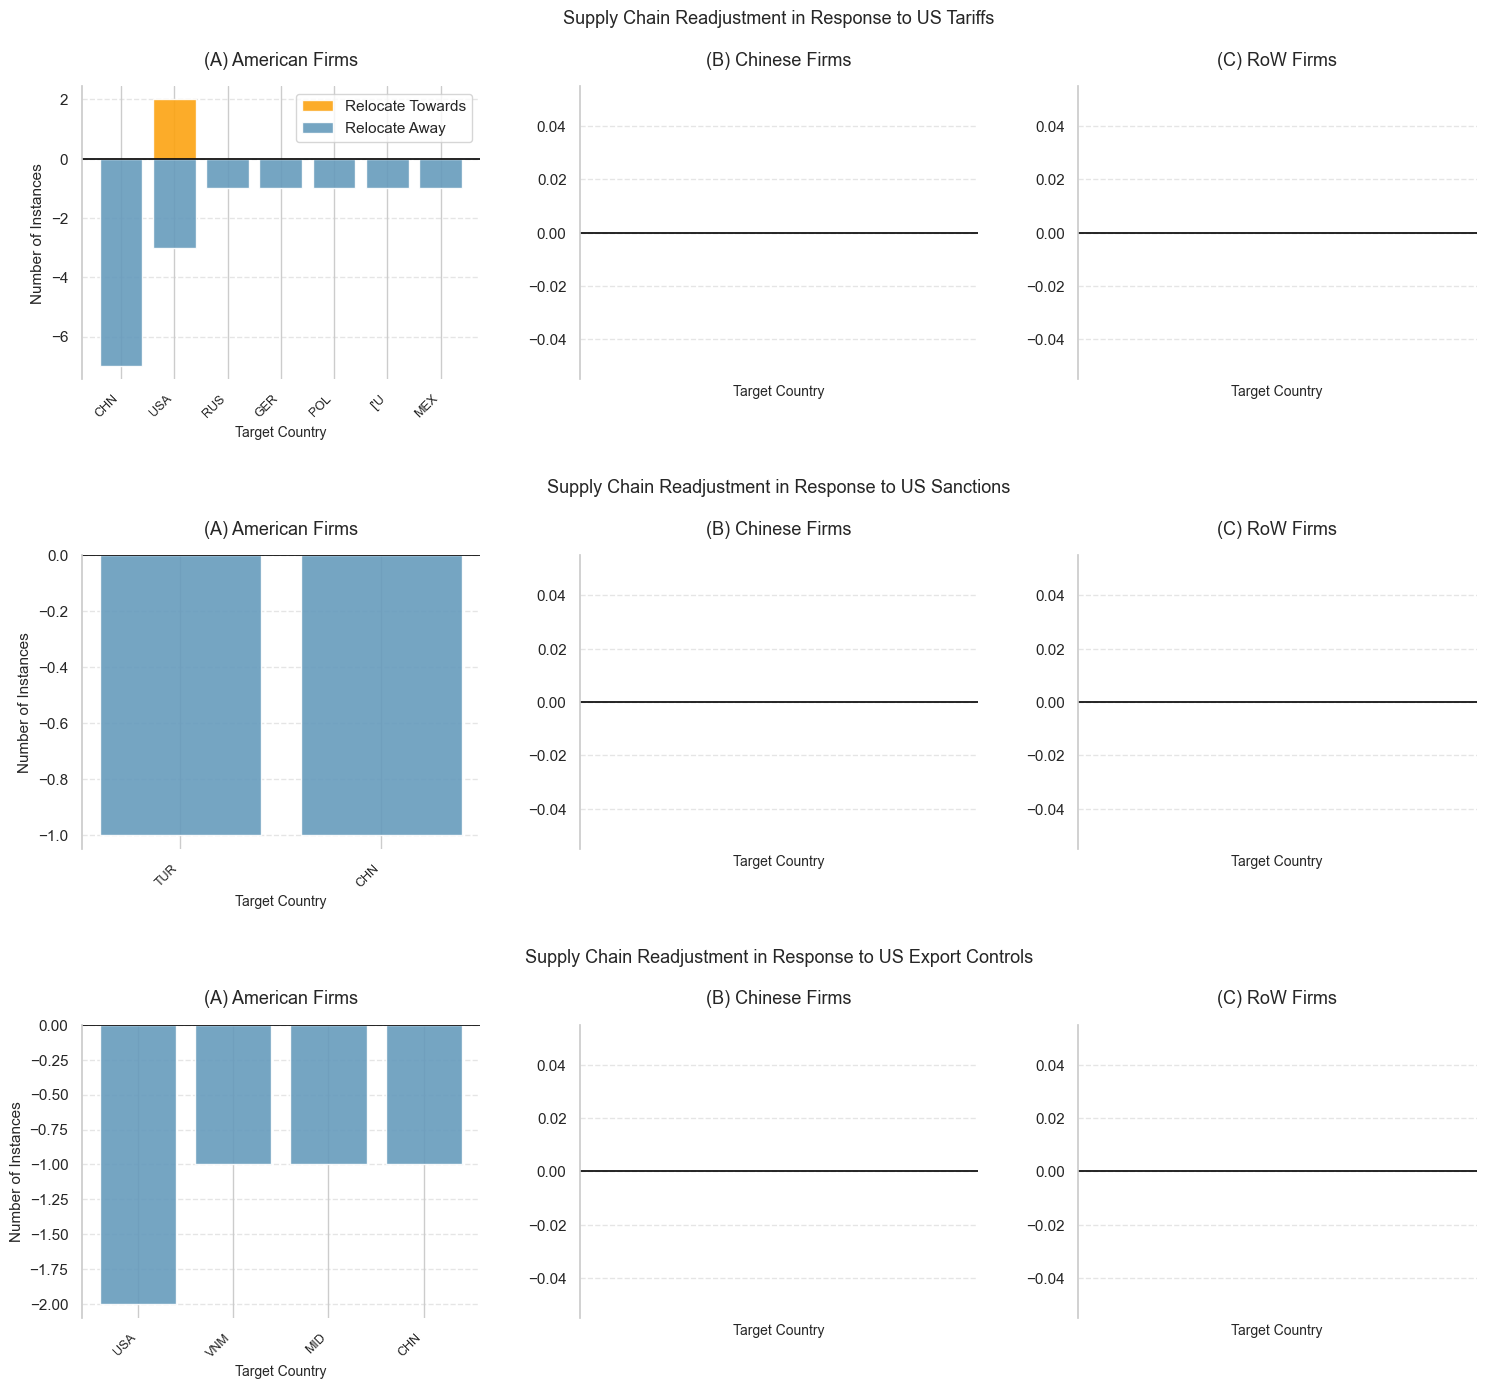

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import yfinance as yf

country_cache = {}

def get_country_from_ticker(ticker):
    if pd.isna(ticker): return 'Unknown'
    ticker_str = str(ticker).strip()
    if ticker_str not in country_cache:
        try:
            country_cache[ticker_str] = yf.Ticker(ticker_str).info.get('country', 'United States')
        except:
            country_cache[ticker_str] = 'United States'
    return country_cache[ticker_str]

data_merged['firm_country'] = data_merged['ticker'].apply(get_country_from_ticker)

us_aliases = {'usa', 'us', 'united states', 'america', 'u.s.', 'u.s.a.'}
chn_aliases = {'china', 'chn', 'prc', 'macau', 'hong kong'}

def get_firm_group(country):
    c = str(country).lower().strip()
    if c in us_aliases:
        return 'American Firms'
    elif c in chn_aliases:
        return 'Chinese Firms'
    elif c != 'unknown' and c != 'nan' and c != '':
        return 'RoW Firms'
    return 'Unknown'

data_merged['Firm Group'] = data_merged['firm_country'].apply(get_firm_group)

measures = ['tariffs_any', 'sanctions_any', 'export_controls_any']

noms_mesures = {
    'tariffs_any': 'Tariffs',
    'sanctions_any': 'Sanctions',
    'export_controls_any': 'Export Controls'
}

prefix_map = {
    'tariffs_any': 'tariffs_',
    'sanctions_any': 'sanctions_',
    'export_controls_any': 'exports_'
}

def clean_and_split_countries(val):
    if pd.isna(val): return []
    countries = str(val).split(',')
    res = []
    for c in countries:
        c_cl = c.strip().upper()
        if c_cl:
            if c_cl in ['UNITED STATES', 'US', 'U.S.', 'AMERICA', 'USA']: c_cl = 'USA'
            elif c_cl in ['CHINA', 'PRC', 'CHN']: c_cl = 'CHN'
            elif c_cl in ['MEXICO']: c_cl = 'MEX'
            elif c_cl in ['VIETNAM']: c_cl = 'VNM'
            elif c_cl in ['MALAYSIA']: c_cl = 'MYS'
            elif c_cl in ['INDIA']: c_cl = 'IND'
            elif c_cl in ['TAIWAN']: c_cl = 'TWN'
            elif c_cl in ['THAILAND']: c_cl = 'THA'
            elif c_cl in ['CANADA']: c_cl = 'CAN'
            elif c_cl in ['EUROPEAN UNION', 'EUROPE', 'EU']: c_cl = 'EU'
            elif c_cl in ['RUSSIA']: c_cl = 'RUS'
            elif c_cl in ['KOREA', 'SOUTH KOREA']: c_cl = 'KOR'
            elif c_cl in ['JAPAN']: c_cl = 'JPN'
            elif c_cl in ['INDONESIA']: c_cl = 'IDN'
            elif c_cl in ['SINGAPORE']: c_cl = 'SGP'
            elif c_cl in ['BRAZIL']: c_cl = 'BRA'
            elif c_cl in ['PHILIPPINES']: c_cl = 'PHL'
            elif c_cl in ['UKRAINE']: c_cl = 'UKR'
            elif c_cl in ['BELARUS']: c_cl = 'BLR'
            elif c_cl in ['TURKEY']: c_cl = 'TUR'
            elif c_cl in ['SWEDEN']: c_cl = 'SWE'
            elif c_cl in ['IRAN']: c_cl = 'IRN'
            elif len(c_cl) > 3: c_cl = c_cl[:3]
            res.append(c_cl)
    return res

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
plt.subplots_adjust(hspace=0.6, wspace=0.25)

groups = ['American Firms', 'Chinese Firms', 'RoW Firms']

for i, m_col in enumerate(measures):
    m_name = noms_mesures[m_col]
    prefix = prefix_map[m_col]
    
    if m_col not in data_merged.columns:
        continue
        
    mask = data_merged[m_col].astype(str).str.strip().str.lower().isin(['1', '1.0', 'true', 'yes', 'y', 't'])
    df_m = data_merged[mask].copy()
    
    c_imp = f"{prefix}countries_imposing"
    if c_imp in df_m.columns:
        def is_us_imposing(val):
            if pd.isna(val): return False
            return any(u in str(val).lower() for u in us_aliases)
        df_m = df_m[df_m[c_imp].apply(is_us_imposing)]
        
    c_toward = f"{prefix}countries_supply_chain_adj_towards"
    c_away = f"{prefix}countries_supply_chain_adj_away"
    
    for j, group in enumerate(groups):
        ax = axes[i, j]
        df_g = df_m[df_m['Firm Group'] == group]
        
        counts_toward = {}
        counts_away = {}
        
        if c_toward in df_g.columns:
            for val in df_g[c_toward]:
                for c in clean_and_split_countries(val):
                    counts_toward[c] = counts_toward.get(c, 0) + 1
                    
        if c_away in df_g.columns:
            for val in df_g[c_away]:
                for c in clean_and_split_countries(val):
                    counts_away[c] = counts_away.get(c, 0) + 1
                    
        all_countries = list(set(list(counts_toward.keys()) + list(counts_away.keys())))
        all_countries.sort(key=lambda x: (counts_away.get(x, 0) + counts_toward.get(x, 0)), reverse=True)
        all_countries = all_countries[:15]
        
        x_vals = np.arange(len(all_countries))
        y_toward = [counts_toward.get(c, 0) for c in all_countries]
        y_away = [-counts_away.get(c, 0) for c in all_countries]
        
        ax.bar(x_vals, y_toward, color='#fca311', label='Relocate Towards', alpha=0.9)
        ax.bar(x_vals, y_away, color='#669bbc', label='Relocate Away', alpha=0.9)
        
        ax.axhline(0, color='black', linewidth=1.2)
        ax.set_xticks(x_vals)
        ax.set_xticklabels(all_countries, rotation=45, ha='right', fontsize=9)
        ax.spines[['top', 'right', 'bottom']].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        if i == 0 and j == 1:
            ax.set_title(f"Supply Chain Readjustment in Response to US {m_name}\n\n({chr(65+j)}) {group}", fontsize=13, pad=15)
        elif j == 1:
            ax.set_title(f"Supply Chain Readjustment in Response to US {m_name}\n\n({chr(65+j)}) {group}", fontsize=13, pad=15)
        else:
            ax.set_title(f"({chr(65+j)}) {group}", fontsize=13, pad=15)
            
        if j == 0:
            ax.set_ylabel("Number of Instances", fontsize=11)
            
        ax.set_xlabel("Target Country", fontsize=10)
        
        if i == 0 and j == 0:
            ax.legend(loc='upper right', frameon=True)
            
plt.show()

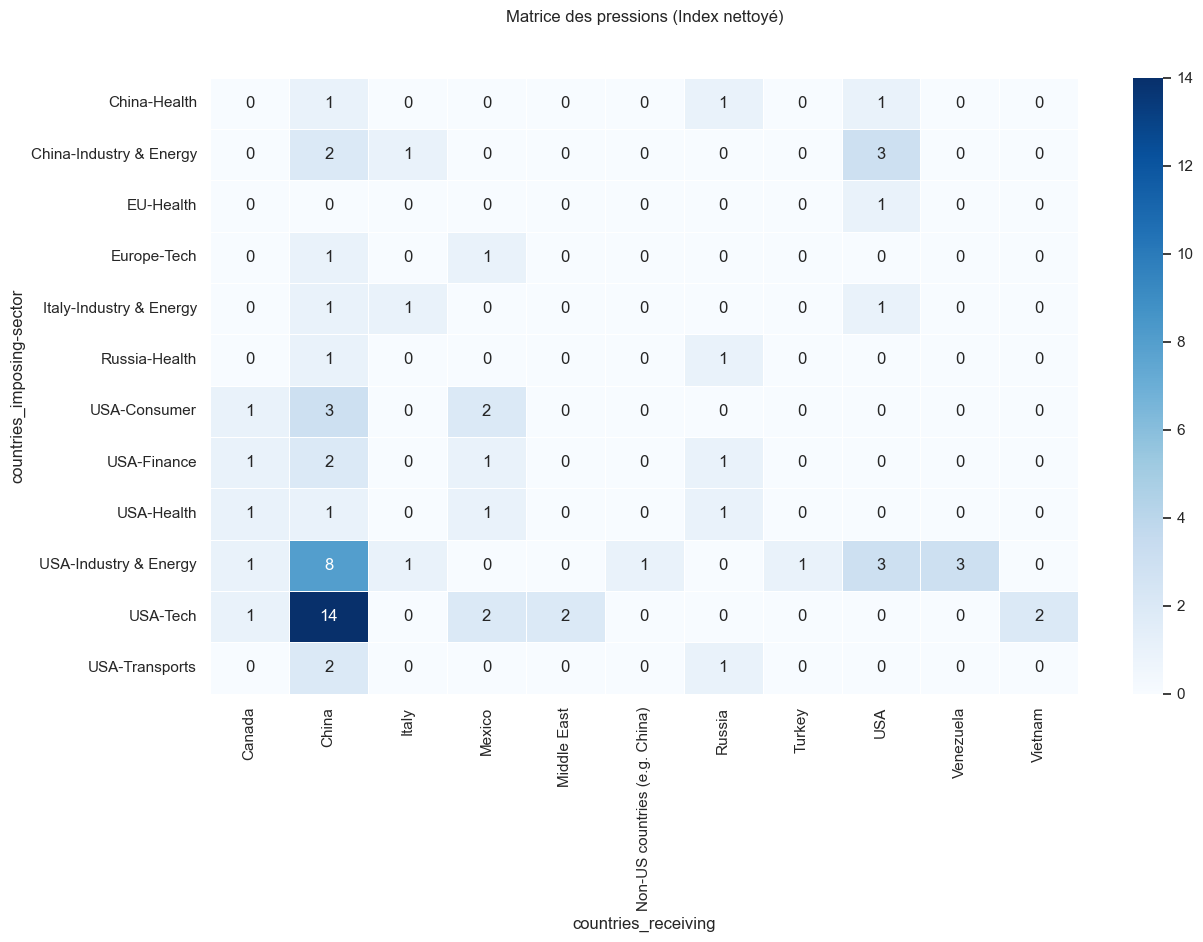

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data_merged_2 = data_merged.copy()
all_pressures = []
prefix_map = {
    'tariffs_effect_any': 'tariffs_',
    'effect_any': '',
    'export_controls_any': 'exports_',
    'sanctions_any': 'sanctions_'
}

for measure_col, prefix in prefix_map.items():
    if measure_col in data_merged_2.columns:
        col_imp = f"{prefix}countries_imposing"
        col_rec = f"{prefix}countries_receiving"
        
        if col_imp in data_merged_2.columns and col_rec in data_merged_2.columns:
            temp_df = data_merged_2[data_merged_2[measure_col] == 1][[col_imp, col_rec, 'sector']].copy()
            if not temp_df.empty:
                temp_df.columns = ['countries_imposing', 'countries_receiving', 'sector']
                all_pressures.append(temp_df)

if not all_pressures:
    print("❌ Aucune donnée trouvée.")
else:
    df_matrix = pd.concat(all_pressures, ignore_index=True)
    
    # Nettoyage
    df_matrix = df_matrix.replace(['', 'nan', 'NaN', 'None'], pd.NA).dropna()

    # Explode
    df_matrix['countries_imposing'] = df_matrix['countries_imposing'].astype(str).str.split(',')
    df_matrix['countries_receiving'] = df_matrix['countries_receiving'].astype(str).str.split(',')
    df_matrix = df_matrix.explode('countries_imposing').explode('countries_receiving')

    # --- ÉTAPE CRUCIALE : On force un nouvel index unique pour éviter le ValueError ---
    df_matrix = df_matrix.reset_index(drop=True)

    # Nettoyage final des strings
    for col in ['countries_imposing', 'countries_receiving', 'sector']:
        df_matrix[col] = df_matrix[col].astype(str).str.strip()
        df_matrix = df_matrix[df_matrix[col] != 'nan']
        df_matrix = df_matrix[df_matrix[col] != '']

    # Maintenant crosstab fonctionnera sans conflit d'index
    matrix = pd.crosstab(
        index=[df_matrix['countries_imposing'], df_matrix['sector']],
        columns=df_matrix['countries_receiving']
    )

    if matrix.empty:
        print("❌ La matrice est vide après filtrage.")
    else:
        plt.figure(figsize=(14, max(8, len(matrix) * 0.45)))
        sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", linewidths=.5)
        plt.title("Matrice des pressions (Index nettoyé)", pad=40)
        plt.show()

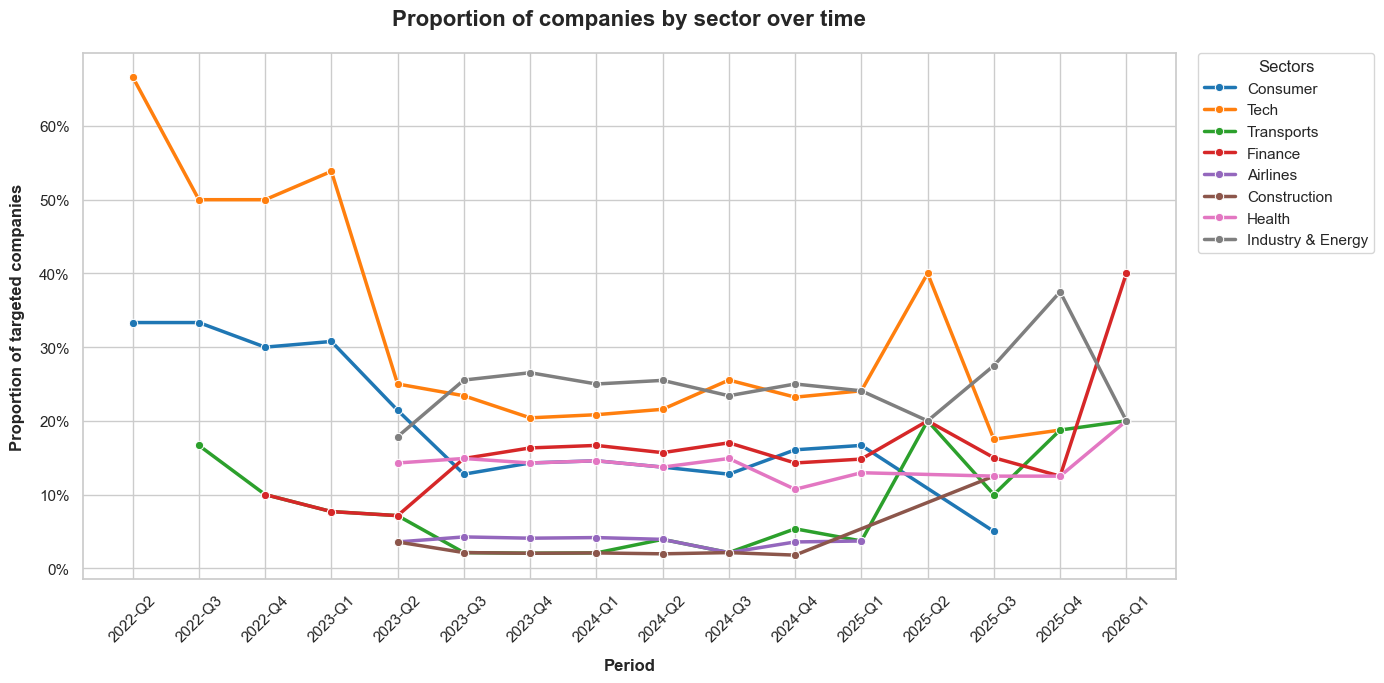

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

df_time = data_merged_2.copy()

df_time['period'] = df_time['year'].astype(str) + '-' + df_time['quarter'].astype(str)

evolution_sector = df_time.groupby(['period', 'sector'])['company'].nunique().reset_index(name='sector_count')
evolution_total = df_time.groupby('period')['company'].nunique().reset_index(name='total_count')

evolution = pd.merge(evolution_sector, evolution_total, on='period')

evolution['ratio'] = evolution['sector_count'] / evolution['total_count']

evolution = evolution.sort_values('period')

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=evolution,
    x='period',
    y='ratio',
    hue='sector',
    marker='o',      
    linewidth=2.5,   
    palette="tab10"  
)

plt.title("Proportion of companies by sector over time", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Period", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Proportion of targeted companies", fontsize=12, fontweight='bold', labelpad=10)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(rotation=45)
plt.legend(title="Sectors", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig("evolution_sectors.png", dpi=300, bbox_inches='tight')
plt.show()

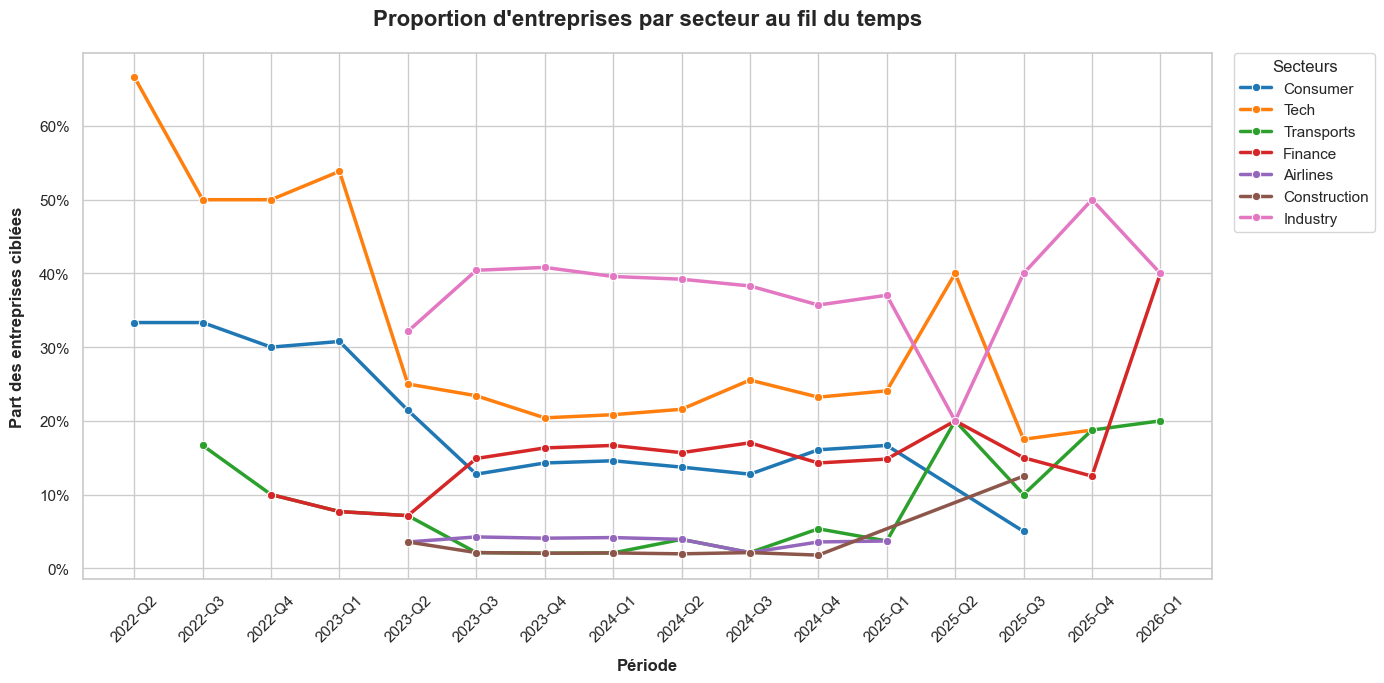

In [110]:
# fusionner les sectuers Industry & Energy et Health en "Industry"
data_merged_2.loc[data_merged_2['sector'].isin(['Industry & Energy', 'Health']), 'sector'] = 'Industry'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

df_time = data_merged_2.copy()

df_time['period'] = df_time['year'].astype(str) + '-' + df_time['quarter'].astype(str)

evolution_sector = df_time.groupby(['period', 'sector'])['company'].nunique().reset_index(name='sector_count')
evolution_total = df_time.groupby('period')['company'].nunique().reset_index(name='total_count')

evolution = pd.merge(evolution_sector, evolution_total, on='period')

evolution['ratio'] = evolution['sector_count'] / evolution['total_count']

evolution = evolution.sort_values('period')

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=evolution,
    x='period',
    y='ratio',
    hue='sector',
    marker='o',      
    linewidth=2.5,   
    palette="tab10"  
)

plt.title("Proportion d'entreprises par secteur au fil du temps", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Période", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Part des entreprises ciblées", fontsize=12, fontweight='bold', labelpad=10)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(rotation=45)
plt.legend(title="Secteurs", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

Périodes analysées : ['2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4', '2026-Q1']
Périodes analysées pour l'échantillon : ['2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4', '2026-Q1']



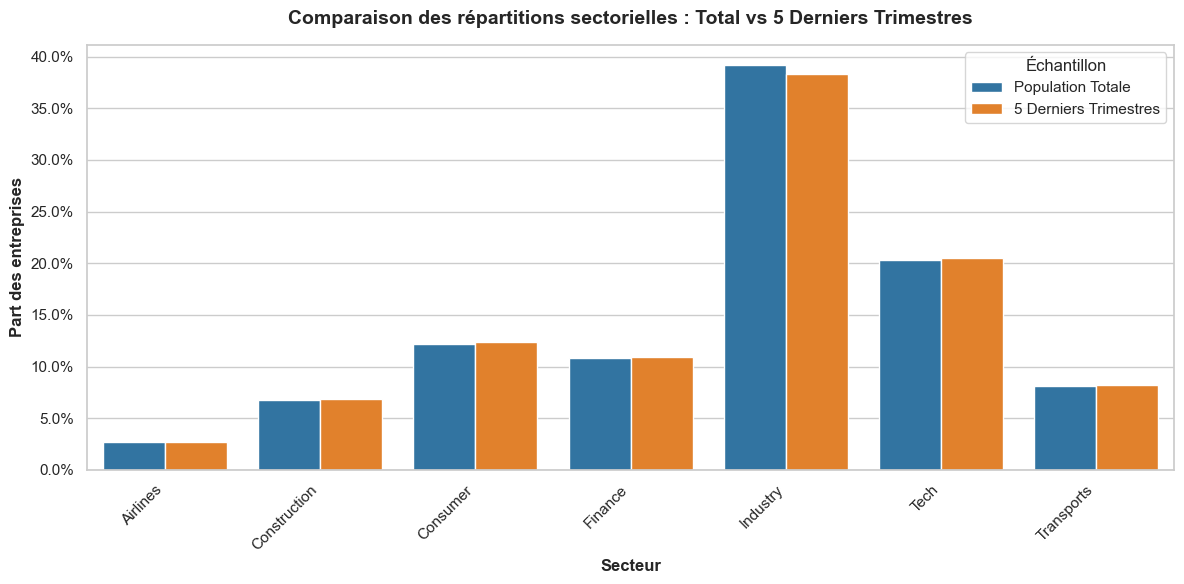

--------------------------------------------------
RÉSULTATS DU TEST DE REPRÉSENTATIVITÉ (Chi-Deux)
--------------------------------------------------
Taille de la population globale : 74 entreprises
Taille de l'échantillon récent : 73 entreprises

Statistique du Chi-Deux : 0.0213
P-value : 1.0000

✅ CONCLUSION : La p-value est > 0.05.
Il n'y a pas de différence statistiquement significative.
=> Les 5 derniers trimestres sont un échantillon REPRÉSENTATIF de votre population globale.


In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chisquare
from matplotlib.ticker import PercentFormatter

df_rep = data_merged_2.copy()

df_rep['period'] = df_rep['year'].astype(str).str.replace('.0', '', regex=False) + '-' + df_rep['quarter'].astype(str).str.replace('.0', '', regex=False)

uniques = [p for p in df_rep['period'].unique() if isinstance(p, str) and p != 'nan-nan']
periodes_triees = sorted(uniques)

cinq_derniers_trimestres = periodes_triees[-5:]

print(f"Périodes analysées : {cinq_derniers_trimestres}")

df_final_sample = df_rep[df_rep['period'].isin(cinq_derniers_trimestres)].copy()

print(f"Périodes analysées pour l'échantillon : {cinq_derniers_trimestres}\n")

# 2. POPULATION GLOBALE (Toutes les entreprises uniques)
# On ne garde qu'une seule occurrence par entreprise pour avoir sa vraie pondération
pop_totale = df_rep.drop_duplicates(subset=['company'])
total_entreprises = len(pop_totale)
repartition_totale = pop_totale['sector'].value_counts(normalize=True).sort_index()

# 3. ECHANTILLON (Entreprises uniques des 5 derniers trimestres)
df_recent = df_rep[df_rep['period'].isin(cinq_derniers_trimestres)]
pop_recente = df_recent.drop_duplicates(subset=['company'])
total_recent = len(pop_recente)
repartition_recente = pop_recente['sector'].value_counts(normalize=True).sort_index()

# 4. ALIGNEMENT DES DONNÉES (au cas où un secteur serait absent des 5 derniers trimestres)
# On s'assure que les deux séries ont les mêmes index (secteurs)
secteurs_communs = repartition_totale.index.union(repartition_recente.index)
repartition_totale = repartition_totale.reindex(secteurs_communs, fill_value=0)
repartition_recente = repartition_recente.reindex(secteurs_communs, fill_value=0)

# Préparation du DataFrame pour le graphique
df_plot_pop = pd.DataFrame({'Secteur': secteurs_communs, 'Proportion': repartition_totale, 'Groupe': 'Population Totale'})
df_plot_rec = pd.DataFrame({'Secteur': secteurs_communs, 'Proportion': repartition_recente, 'Groupe': '5 Derniers Trimestres'})
df_comparaison = pd.concat([df_plot_pop, df_plot_rec])

# --- TRACÉ DU GRAPHIQUE ---
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_comparaison, 
    x='Secteur', 
    y='Proportion', 
    hue='Groupe',
    palette=['#1f77b4', '#ff7f0e']
)

plt.title("Comparaison des répartitions sectorielles : Total vs 5 Derniers Trimestres", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Part des entreprises", fontweight='bold')
plt.xlabel("Secteur", fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Formatage de l'axe Y en pourcentages
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend(title="Échantillon", loc='upper right')
plt.tight_layout()
plt.show()

# --- 5. TEST STATISTIQUE DU CHI-DEUX ---
# Pour le test, on a besoin des effectifs (comptages réels) attendus vs observés
# Observé : le vrai nombre d'entreprises par secteur dans les 5 derniers trimestres
effectifs_observes = pop_recente['sector'].value_counts().reindex(secteurs_communs, fill_value=0)

# Attendu : ce qu'on aurait dû avoir si les proportions totales s'appliquaient parfaitement à l'échantillon
effectifs_attendus = repartition_totale * total_recent

# Exécution du test
chi2_stat, p_value = chisquare(f_obs=effectifs_observes, f_exp=effectifs_attendus)

print("-" * 50)
print("RÉSULTATS DU TEST DE REPRÉSENTATIVITÉ (Chi-Deux)")
print("-" * 50)
print(f"Taille de la population globale : {total_entreprises} entreprises")
print(f"Taille de l'échantillon récent : {total_recent} entreprises\n")
print(f"Statistique du Chi-Deux : {chi2_stat:.4f}")
print(f"P-value : {p_value:.4f}\n")

if p_value > 0.05:
    print("✅ CONCLUSION : La p-value est > 0.05.")
    print("Il n'y a pas de différence statistiquement significative.")
    print("=> Les 5 derniers trimestres sont un échantillon REPRÉSENTATIF de votre population globale.")
else:
    print("❌ CONCLUSION : La p-value est <= 0.05.")
    print("Il y a une différence statistiquement significative.")
    print("=> Les 5 derniers trimestres NE SONT PAS représentatifs de la population globale (certains secteurs sont sur/sous-représentés).")

------------------------------------------------------------
RÉCAPITULATIF DE LA REPRÉSENTATIVITÉ PAR TRIMESTRE
------------------------------------------------------------
Période  Nombre_Entreprises  P_Value Représentatif
2022-Q2                   3 0.388471           Oui
2022-Q3                   6 0.177150           Oui
2022-Q4                  10 0.064430           Oui
2023-Q1                  13 0.008000           Non
2023-Q2                  28 0.741324           Oui
2023-Q3                  47 0.547943           Oui
2023-Q4                  49 0.448695           Oui
2024-Q1                  48 0.440852           Oui
2024-Q2                  51 0.624699           Oui
2024-Q3                  47 0.427273           Oui
2024-Q4                  56 0.613576           Oui
2025-Q1                  54 0.294704           Oui
2025-Q2                   5 0.707272           Oui
2025-Q3                  40 0.457043           Oui
2025-Q4                  16 0.397721           Oui
2026-Q1    

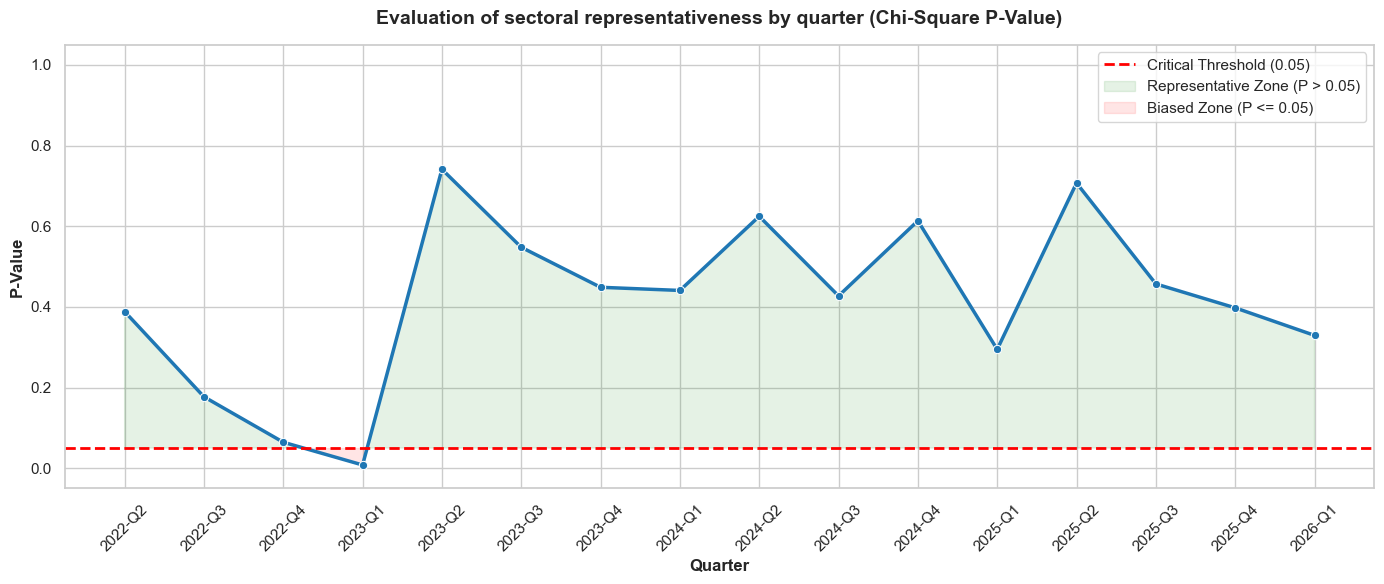

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare

df_rep = data_merged_2.copy()

df_rep['period'] = df_rep['year'].astype(str).str.replace('.0', '', regex=False) + '-' + df_rep['quarter'].astype(str).str.replace('.0', '', regex=False)

periodes_uniques = [p for p in df_rep['period'].unique() if isinstance(p, str) and 'nan' not in p]
periodes_triees = sorted(periodes_uniques)

pop_totale = df_rep.drop_duplicates(subset=['company'])

# 2. POPULATION GLOBALE (La référence)
pop_totale = df_rep.drop_duplicates(subset=['company'])
repartition_totale = pop_totale['sector'].value_counts(normalize=True).sort_index()
secteurs_ref = repartition_totale.index

resultats_tests = []

# 3. BOUCLE SUR CHAQUE TRIMESTRE
for periode in periodes_triees:
    # Isoler les données du trimestre
    df_periode = df_rep[df_rep['period'] == periode]
    pop_periode = df_periode.drop_duplicates(subset=['company'])
    total_periode = len(pop_periode)
    
    # Si très peu d'entreprises, le test du Chi-Deux n'est pas fiable, mais on le calcule quand même
    if total_periode == 0:
        continue
        
    # Effectifs observés dans ce trimestre (alignés sur les secteurs de référence)
    effectifs_observes = pop_periode['sector'].value_counts().reindex(secteurs_ref, fill_value=0)
    
    # Effectifs attendus si la répartition était parfaite
    effectifs_attendus = repartition_totale * total_periode
    
    # Test du Chi-Deux
    # Attention: chisquare peut renvoyer un warning si des effectifs attendus sont à 0. 
    # On s'assure qu'aucun effectif attendu n'est strictement 0 (on ajoute un epsilon si besoin, mais ici la ref est globale donc >0)
    chi2_stat, p_value = chisquare(f_obs=effectifs_observes, f_exp=effectifs_attendus)
    
    resultats_tests.append({
        'Période': periode,
        'Nombre_Entreprises': total_periode,
        'Chi2_Stat': chi2_stat,
        'P_Value': p_value,
        'Représentatif': 'Oui' if p_value > 0.05 else 'Non'
    })

# Création d'un DataFrame de résultats
df_resultats = pd.DataFrame(resultats_tests)

# Affichage du tableau récapitulatif dans la console
print("-" * 60)
print("RÉCAPITULATIF DE LA REPRÉSENTATIVITÉ PAR TRIMESTRE")
print("-" * 60)
print(df_resultats[['Période', 'Nombre_Entreprises', 'P_Value', 'Représentatif']].to_string(index=False))
print("-" * 60)

# --- 4. TRACÉ DU GRAPHIQUE ---
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Tracé principal
ax = sns.lineplot(
    data=df_resultats, 
    x='Période', 
    y='P_Value', 
    marker='o',
    linewidth=2.5,
    color='#1f77b4'
)

# Ligne rouge du seuil de significativité (0.05)
plt.axhline(0.05, color='red', linestyle='--', linewidth=2, label='Critical Threshold (0.05)')

# Coloriage des zones
plt.fill_between(df_resultats['Période'], df_resultats['P_Value'], 0.05, 
                 where=(df_resultats['P_Value'] > 0.05), interpolate=True, color='green', alpha=0.1, label='Representative Zone (P > 0.05)')
plt.fill_between(df_resultats['Période'], df_resultats['P_Value'], 0.05, 
                 where=(df_resultats['P_Value'] <= 0.05), interpolate=True, color='red', alpha=0.1, label='Biased Zone (P <= 0.05)')

plt.title("Evaluation of sectoral representativeness by quarter (Chi-Square P-Value)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("P-Value", fontweight='bold')
plt.xlabel("Quarter", fontweight='bold')
plt.xticks(rotation=45)
plt.ylim(-0.05, 1.05)  # The p-value is between 0 and 1

plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("representativeness_over_time.png", dpi=300, bbox_inches='tight')
plt.show()

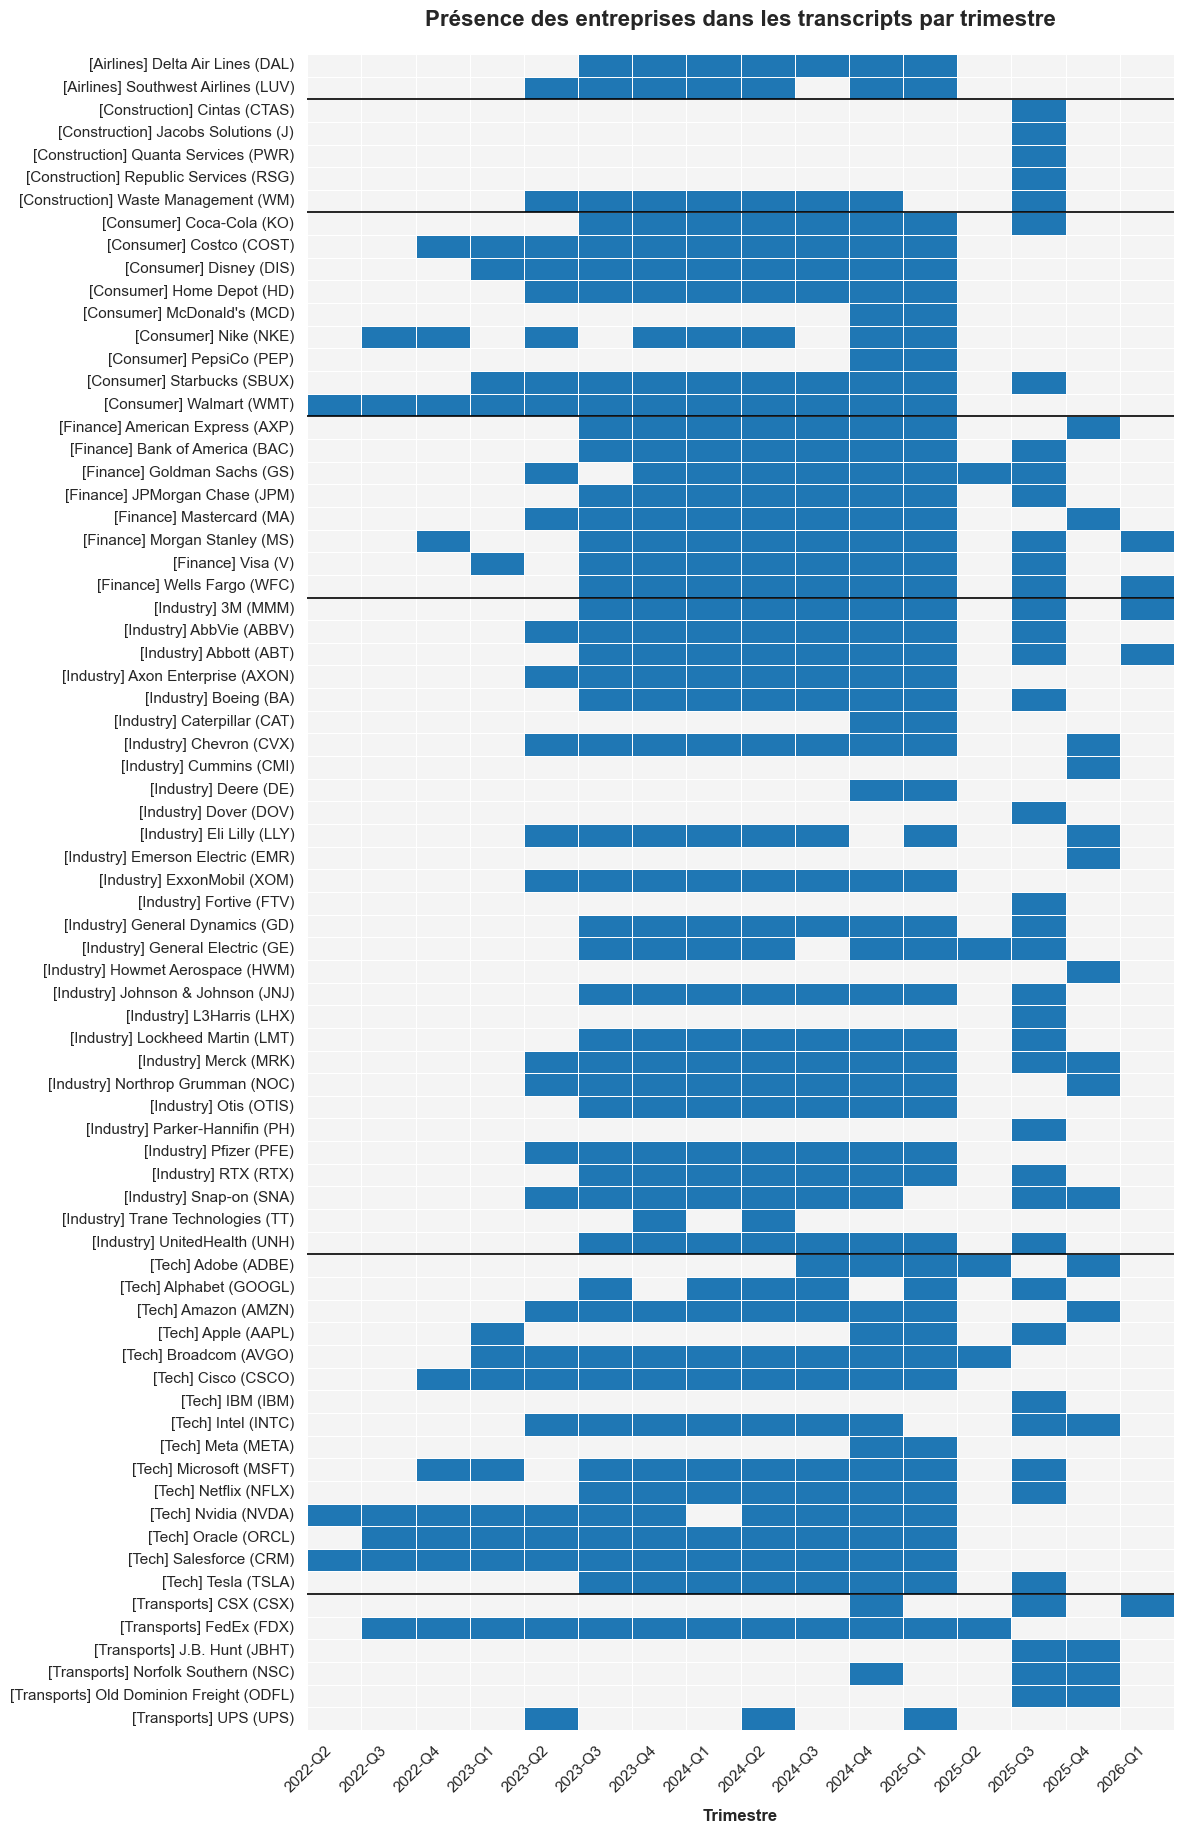

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_vis = data_merged_2.copy()

# 1. Création de la variable temporelle
df_vis['period'] = df_vis['year'].astype(str) + '-' + df_vis['quarter'].astype(str)

# 2. Création de la matrice de présence
# On garde une seule ligne par entreprise et par trimestre
presence = df_vis.drop_duplicates(subset=['company', 'sector', 'period']).copy()
presence['present'] = 1

# On pivote pour avoir les entreprises en lignes et les trimestres en colonnes
matrix = presence.pivot_table(
    index=['sector', 'company'], 
    columns='period', 
    values='present', 
    fill_value=0
)

# 3. Tri et formatage pour un affichage propre
# Le tri par secteur regroupe visuellement les entreprises similaires
matrix = matrix.sort_index(level=['sector', 'company'])

# On formate les étiquettes de l'axe Y pour afficher le secteur et l'entreprise
matrix.index = [f"[{sec}] {comp}" for sec, comp in matrix.index]

# 4. Tracé du graphique
# La hauteur s'adapte dynamiquement au nombre d'entreprises
plt.figure(figsize=(12, max(8, len(matrix) * 0.25)))
sns.set_theme(style="white")

# Création d'une palette binaire : gris clair (absent, 0) et bleu foncé (présent, 1)
cmap = sns.color_palette(["#f4f4f4", "#1f77b4"])

ax = sns.heatmap(
    matrix, 
    cmap=cmap, 
    linewidths=0.5,       # Ajoute un léger quadrillage
    linecolor='white', 
    cbar=False            # On retire la légende de couleur inutile (c'est du binaire)
)

plt.title("Présence des entreprises dans les transcripts par trimestre", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Trimestre", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("", fontsize=12) # L'axe Y est assez évident, pas besoin de label

# Amélioration de la lisibilité de l'axe X
plt.xticks(rotation=45, ha='right')

# Ajout de lignes horizontales pour séparer visuellement les secteurs
secteurs = [label.split("] ")[0] for label in matrix.index]
for i in range(1, len(secteurs)):
    if secteurs[i] != secteurs[i-1]:
        ax.axhline(i, color='black', linewidth=1.2)

plt.tight_layout()
plt.savefig("heatmap_presence.png", dpi=300)
plt.show()


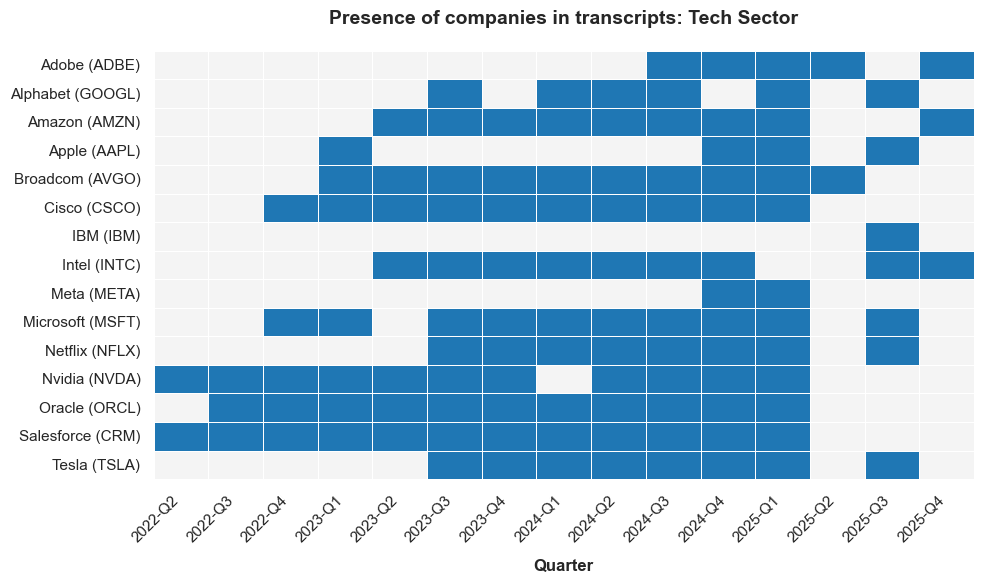

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_vis = data_merged_2.copy()

df_vis = df_vis[df_vis['sector'].str.contains('Tech', na=False, case=False)]

df_vis['period'] = df_vis['year'].astype(str) + '-' + df_vis['quarter'].astype(str)

presence = df_vis.drop_duplicates(subset=['company', 'period']).copy()
presence['present'] = 1

matrix = presence.pivot_table(
    index='company', 
    columns='period', 
    values='present', 
    fill_value=0
)

matrix = matrix.sort_index()

plt.figure(figsize=(10, max(6, len(matrix) * 0.35)))
sns.set_theme(style="white")

cmap = sns.color_palette(["#f4f4f4", "#1f77b4"])

ax = sns.heatmap(
    matrix, 
    cmap=cmap, 
    linewidths=0.5,       
    linecolor='white', 
    cbar=False            
)

plt.title("Presence of companies in transcripts: Tech Sector", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Quarter", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("", fontsize=12) 

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("heatmap_presence_tech.png", dpi=300)
plt.show()

In [115]:
import pandas as pd

# 1. Chargement et nettoyage des données temporelles
df_temp = df.dropna(subset=['year', 'quarter']).copy()
df_temp['year'] = df_temp['year'].astype(int)

# 2. Comptage des observations par année et trimestre
distribution = df_temp.groupby(['year', 'quarter']).size().reset_index(name='Count')

# 3. Pivot pour obtenir le format horizontal (Multi-index en colonnes)
table_3 = distribution.set_index(['year', 'quarter']).T

# Affichage
print("Table 3: Temporal Distribution of Observations")
print(table_3)

Table 3: Temporal Distribution of Observations
year    2022        2023             2024             2025            2026
quarter   Q2 Q3  Q4   Q1  Q2  Q3  Q4   Q1  Q2  Q3  Q4   Q1 Q2  Q3  Q4   Q1
Count      3  6  10   13  28  47  49   48  51  47  59   54  5  43  16    5


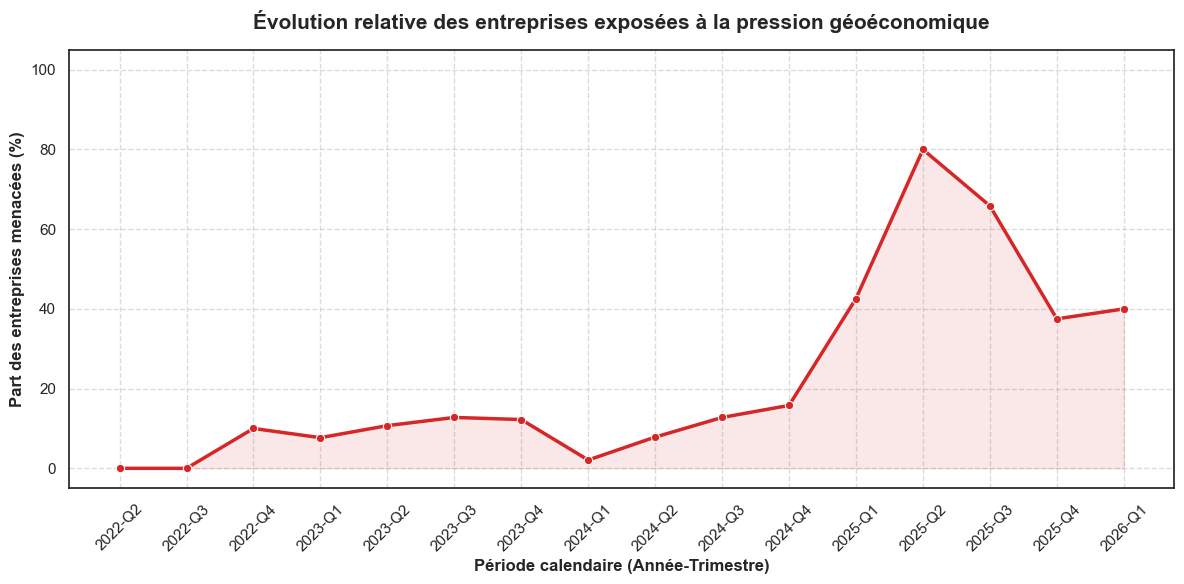

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PRÉPARATION DES DONNÉES TEMPORELLES ---
# Assurez-vous que 'year' et 'quarter' sont bien définis dans votre df (ex: df = data)
df = data.copy() # On travaille sur la base nettoyée
df['period'] = df['year'].astype(str) + '-' + df['quarter'].astype(str)

# Créer une colonne binaire indiquant si une entreprise est "menacée"
# CORRECTION : Utilisation des noms de colonnes validés par Mistral
df['is_threatened'] = df[['tariffs_effect_any', 'exports_effect_any', 'sanctions_effect_any']].apply(
    lambda x: x.astype(str).str.lower().isin(['1', '1.0', 'true', 'yes', 'y', 't']).any(), axis=1
)

# --- 2. CALCUL DE L'ÉVOLUTION RELATIVE ---
# Calcul du nombre d'entreprises menacées par trimestre / Total par trimestre
df_evolution = df.groupby('period')['is_threatened'].agg(['sum', 'count'])
df_evolution['relative_share'] = df_evolution['sum'] / df_evolution['count']

# Convertir en pourcentage pour l'affichage
df_evolution['relative_share_pct'] = df_evolution['relative_share'] * 100

# --- 3. VISUALISATION ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_evolution, x=df_evolution.index, y='relative_share_pct', marker='o', linewidth=2.5, color='#d62728')
plt.ylabel("Part des entreprises menacées (%)", fontweight='bold')
plt.title("Évolution relative des entreprises exposées à la pression géoéconomique", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Période calendaire (Année-Trimestre)", fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-5, 105) # Pour bien voir l'échelle de 0 à 100%

# Remplissage sous la courbe pour le style
plt.fill_between(df_evolution.index, df_evolution['relative_share_pct'], color='#d62728', alpha=0.1)

plt.tight_layout()
plt.savefig("evolution_entreprises_pct.png", dpi=300)
plt.show()

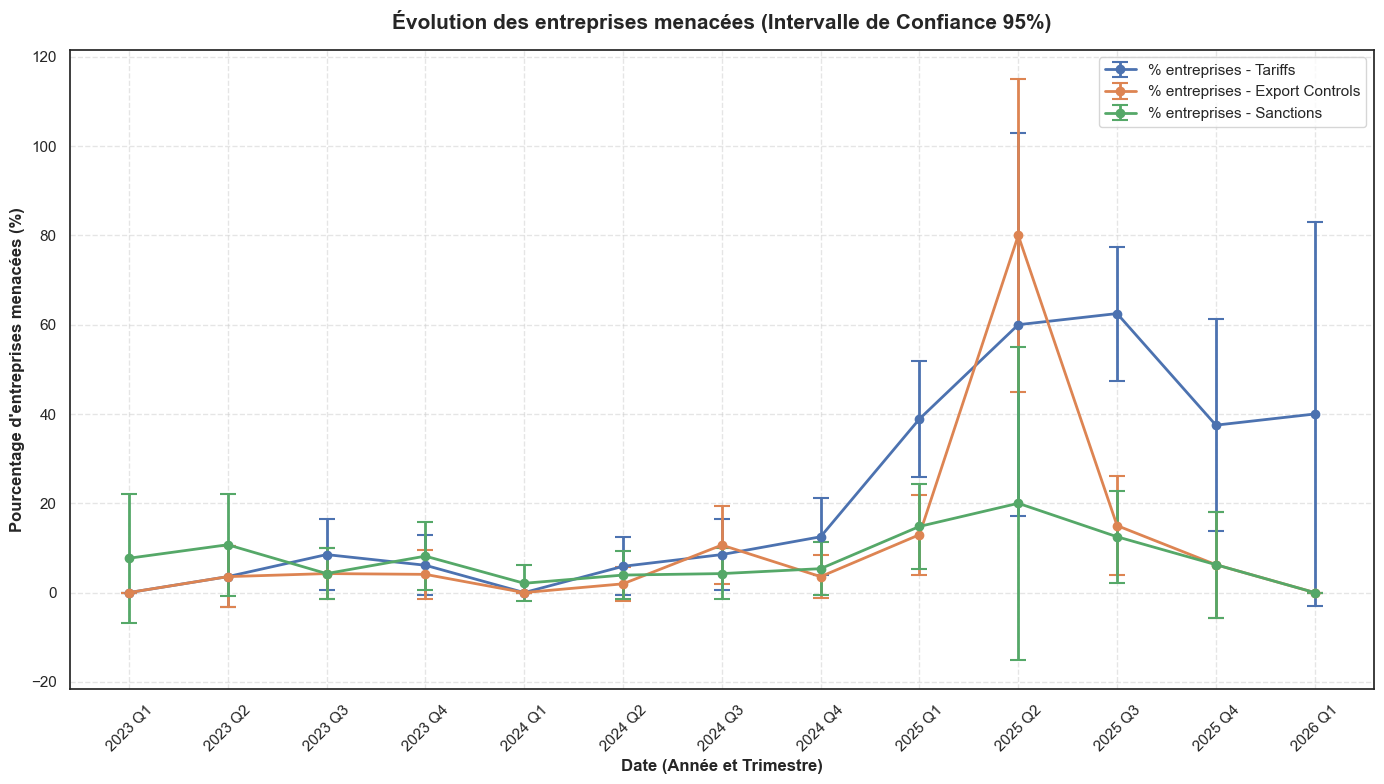

In [117]:
import numpy as np
import matplotlib.pyplot as plt

data = df.copy()

# LES BONS NOMS DE COLONNES
measures = ['tariffs_effect_any', 'exports_effect_any', 'sanctions_effect_any']

# Pour avoir une belle légende sur le graphique
labels_propres = {
    'tariffs_effect_any': 'Tariffs',
    'exports_effect_any': 'Export Controls',
    'sanctions_effect_any': 'Sanctions'
}

# à partir de 2023
data = data[data['year'] >= 2023]

plt.figure(figsize=(14, 8))

for measure in measures:
    # On groupe par année et par trimestre (qui est déjà une chaîne "Q1", "Q2", etc.)
    grouped = data.groupby(['year', 'quarter'])
    
    # Calcul de la proportion (p) et du nombre d'entreprises uniques (n)
    stats_sum = grouped[measure].sum()
    n = grouped['company'].nunique()
    
    p = stats_sum / n
    y = p * 100
    
    # Calcul de l'erreur type (Standard Error) pour une proportion
    se = np.sqrt((p * (1 - p)) / n)
    
    # Marge d'erreur à 95% (1.96 * SE) convertie en %
    ci_margin = 1.96 * se * 100
    
    # Préparation des étiquettes de l'axe X (Année Trimestre)
    x_labels = [f"{year} {quarter}" for year, quarter in y.index]
    x_range = range(len(x_labels))
    
    # Tracé avec moustaches (error bars)
    plt.errorbar(x_range, 
                 y.values, 
                 yerr=ci_margin,     # Taille de la moustache
                 fmt='-o',           # Ligne (-) et points (o)
                 linewidth=2, 
                 capsize=6,          # Largeur de la barre horizontale de la moustache
                 capthick=1.5,       # Épaisseur de la barre de la moustache
                 label=f'% entreprises - {labels_propres[measure]}') # Légende propre

# Configuration des axes et du titre
plt.xticks(x_range, x_labels, rotation=45)
plt.xlabel('Date (Année et Trimestre)', fontweight='bold')
plt.ylabel("Pourcentage d'entreprises menacées (%)", fontweight='bold')
plt.title("Évolution des entreprises menacées (Intervalle de Confiance 95%)", fontsize=15, fontweight='bold', pad=15)

# Ajout d'une grille légère et de la légende
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Sauvegarde et affichage
plt.savefig('evolution_entreprises_moustaches_str.png', dpi=300)
plt.show()

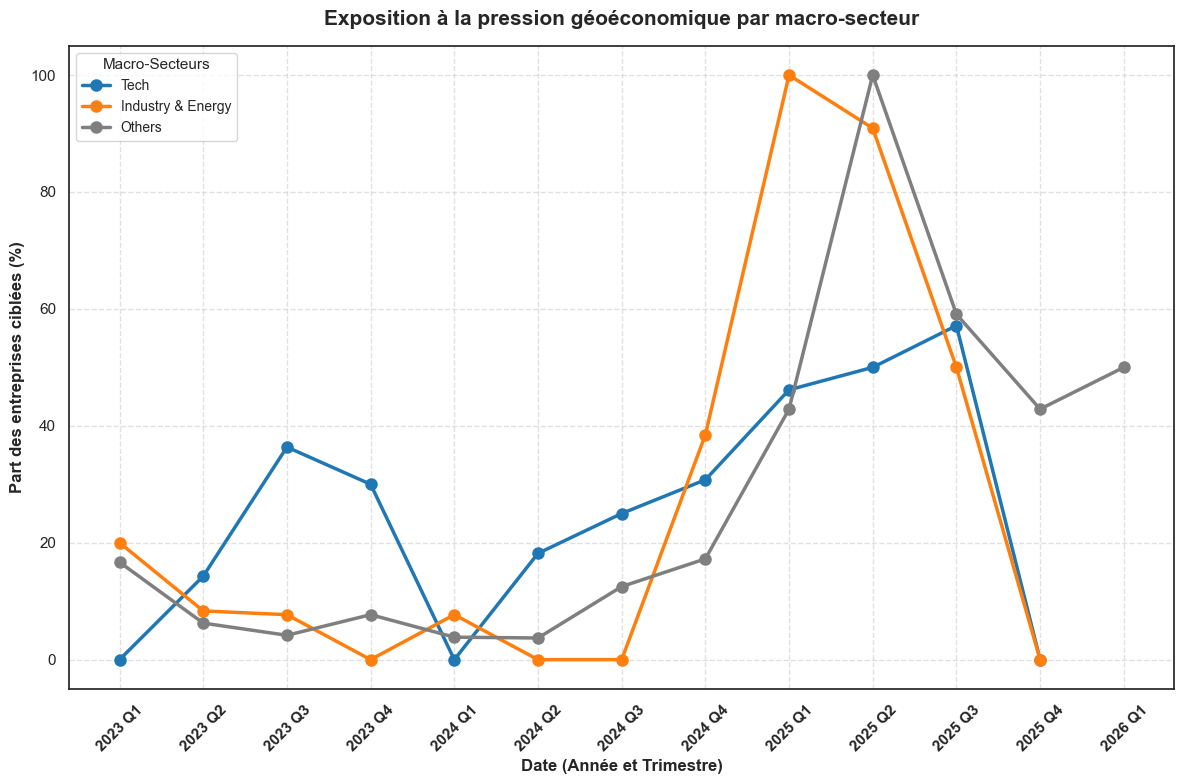

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. On suppose que 'data' est ton dataframe FINAL (celui qui contient déjà la colonne 'sector')
# Si ce n'est pas le cas, assure-toi d'utiliser la variable de ton script précédent qui contient le merge
df_graph = data.copy()

# 2. RECRÉATION DE LA VARIABLE GLOBALE "GEOECONOMIC_ANY"
# Une entreprise est menacée si l'une des trois politiques est à 1 ou True
df_graph['geoeconomic_any'] = df_graph[['tariffs_effect_any', 'exports_effect_any', 'sanctions_effect_any']].apply(
    lambda x: x.astype(str).str.lower().isin(['1', '1.0', 'true', 'yes', 'y', 't']).any(), axis=1
)

# 3. CRÉATION DU GROUPE SECTORIEL
df_graph['sector_grouped'] = df_graph['sector'].apply(
    lambda x: x if x in ['Tech', 'Industry & Energy'] else 'Others'
)

# 4. PRÉPARATION DU GRAPHIQUE
sectors_to_plot = ['Tech', 'Industry & Energy', 'Others']

# On définit un dictionnaire de couleurs pour garder une belle cohérence visuelle
couleurs = {'Tech': '#1f77b4', 'Industry & Energy': '#ff7f0e', 'Others': '#7f7f7f'}

plt.figure(figsize=(12, 8))

for sector in sectors_to_plot:
    sector_data = df_graph[df_graph['sector_grouped'] == sector]
    
    # Sécurité : on vérifie que le sous-groupe n'est pas vide
    if not sector_data.empty:
        # Calcul du pourcentage (Somme des affectés / Nombre d'entreprises uniques)
        stats = sector_data.groupby(['year', 'quarter'])['geoeconomic_any'].sum() / \
                sector_data.groupby(['year', 'quarter'])['company'].nunique() * 100
        
        # Formatage des labels (Année Trimestre)
        x_labels = [f"{int(y)} {q}" for y, q in stats.index]
        x_range = range(len(x_labels))
        
        # Tracé de la ligne avec une couleur spécifique
        plt.plot(x_range, stats.values, marker='o', linewidth=2.5, markersize=8, 
                 label=sector, color=couleurs.get(sector))

# 5. CONFIGURATION DU GRAPHIQUE
plt.xticks(range(len(x_labels)), x_labels, rotation=45, fontweight='bold')
plt.xlabel('Date (Année et Trimestre)', fontweight='bold')
plt.ylabel("Part des entreprises ciblées (%)", fontweight='bold')
plt.title("Exposition à la pression géoéconomique par macro-secteur", fontsize=15, fontweight='bold', pad=15)

# Lignes de grille plus esthétiques
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-5, 105) # On bloque l'axe Y de 0 à 100%

# Légende
plt.legend(title="Macro-Secteurs", title_fontsize='11', fontsize='10', loc='upper left')

plt.tight_layout()

# Sauvegarde et affichage
plt.savefig('evolution_entreprises_pct_groupe.png', dpi=300)
plt.show()

In [119]:
# 1. Création de la catégorie "Others"
data['sector_grouped'] = data['sector'].apply(
    lambda x: x if x in ['Tech', 'Industry & Energy'] else 'Others'
)

sectors_to_plot = ['Tech', 'Industry & Energy', 'Others']

plt.figure(figsize=(12, 8))

for sector in sectors_to_plot:
    sector_data = data[data['sector_grouped'] == sector]
    
    # CALCUL ABSOLU : On fait uniquement la somme des menaces
    # On groupe par période et on additionne les occurrences (is_threatened == 1)
    absolute_counts = sector_data.groupby(['year', 'quarter'])['geoeconomic_any'].sum()
    
    # Formatage des labels
    x_labels = [f"{int(y)} {q}" for y, q in absolute_counts.index]
    x_range = range(len(x_labels))
    
    plt.plot(x_range, absolute_counts.values, marker='o', linewidth=2, label=f'Nb entreprises - {sector}')

# Configuration du graphique
plt.xticks(range(len(x_labels)), x_labels, rotation=45)
plt.xlabel('Date (Année et Trimestre)')
plt.ylabel("Nombre d'entreprises menacées")
plt.title("Évolution absolue du nombre d'entreprises menacées (Tech, Industrie, Others)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Sauvegarde et affichage
plt.savefig('evolution_entreprises_absolu_groupe.png')
plt.show()

KeyError: 'Column not found: geoeconomic_any'

<Figure size 1200x800 with 0 Axes>